Группа М8О-214СВ-24 Терентьев И.В.

In [99]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from scipy import stats
from scipy.stats import shapiro, norm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sktime.classification.kernel_based import RocketClassifier
from sktime.classification.feature_based import Catch22Classifier

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, precision_recall_fscore_support
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', 120)

DATA_DIR = Path("данные")

# EDA

In [100]:

# Маппинг городов к климатическим зонам
CITY_TO_CLIMATE = {
    "Москва": "continental",
    "Санкт-Петербург": "continental",
    "Сочи": "humid_subtropical",
    "Геленджик": "humid_subtropical",
    "Благовещенск": "monsoon_far_east",
    "Находка": "monsoon_far_east",
}

CLIMATE_COLORS = {
    "continental": "#2E86AB",
    "humid_subtropical": "#A23B72", 
    "monsoon_far_east": "#F18F01"
}

def load_all_data(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    frames = []
    for path in sorted(data_dir.glob("*.parquet")):
        city = path.name.split("_")[0]
        df = pd.read_parquet(path).copy().sort_index()
        df["city"] = city
        df["climate"] = CITY_TO_CLIMATE[city]
        frames.append(df)
    
    full = pd.concat(frames).reset_index()
    full = full.rename(columns={"index": "time"})
    full["time"] = pd.to_datetime(full["time"])
    return full.sort_values(["city", "time"]).reset_index(drop=True)

data = load_all_data()
print(f"Загружено: {len(data)} записей")
print(f"Города: {sorted(data['city'].unique())}")
print(f"Период: {data['time'].min()} – {data['time'].max()}")
print(f"Колонки: {list(data.columns)}")

Загружено: 368208 записей
Города: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Колонки: ['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'city', 'climate']


In [101]:
# Проверка пропусков
missing_by_city = data.groupby("city").apply(lambda x: x.isna().sum() / len(x))
print(missing_by_city.round(4))

                 time  temperature_2m  relative_humidity_2m  precipitation  \
city                                                                         
Благовещенск      0.0             0.0                   0.0            0.0   
Геленджик         0.0             0.0                   0.0            0.0   
Москва            0.0             0.0                   0.0            0.0   
Находка           0.0             0.0                   0.0            0.0   
Санкт-Петербург   0.0             0.0                   0.0            0.0   
Сочи              0.0             0.0                   0.0            0.0   

                 rain  snowfall  weathercode  wind_speed_10m  \
city                                                           
Благовещенск      0.0       0.0          0.0             0.0   
Геленджик         0.0       0.0          0.0             0.0   
Москва            0.0       0.0          0.0             0.0   
Находка           0.0       0.0          0.0           

Анализ города: Благовещенск (климат: monsoon_far_east)
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Статистика температуры: мин=-41.9°C, макс=35.0°C, сред=2.2°C


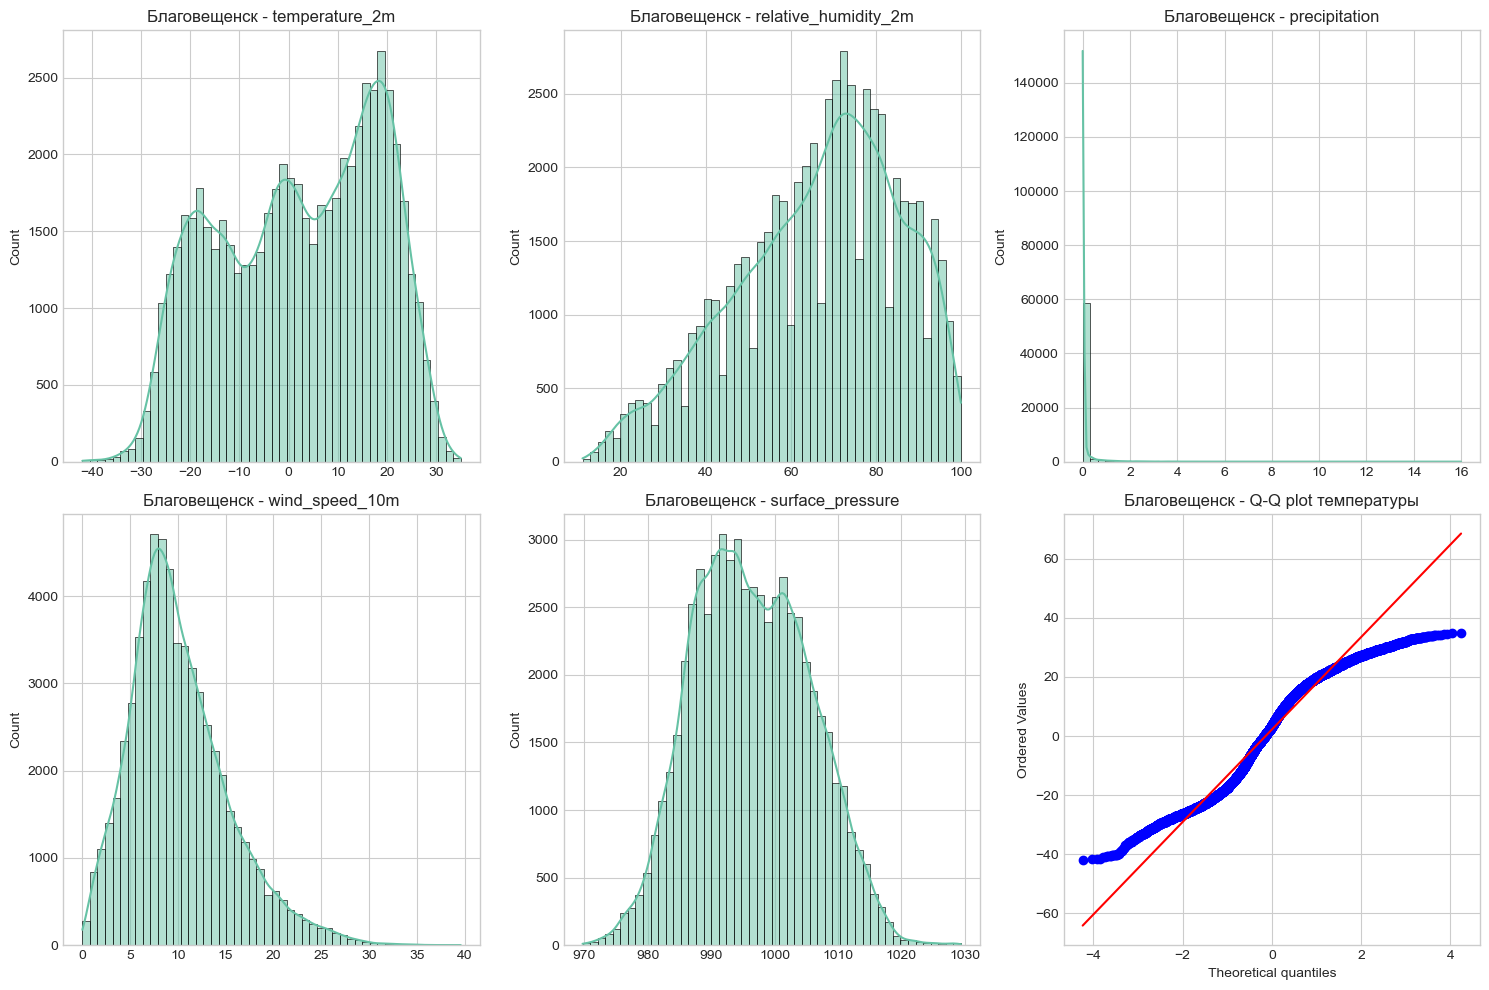

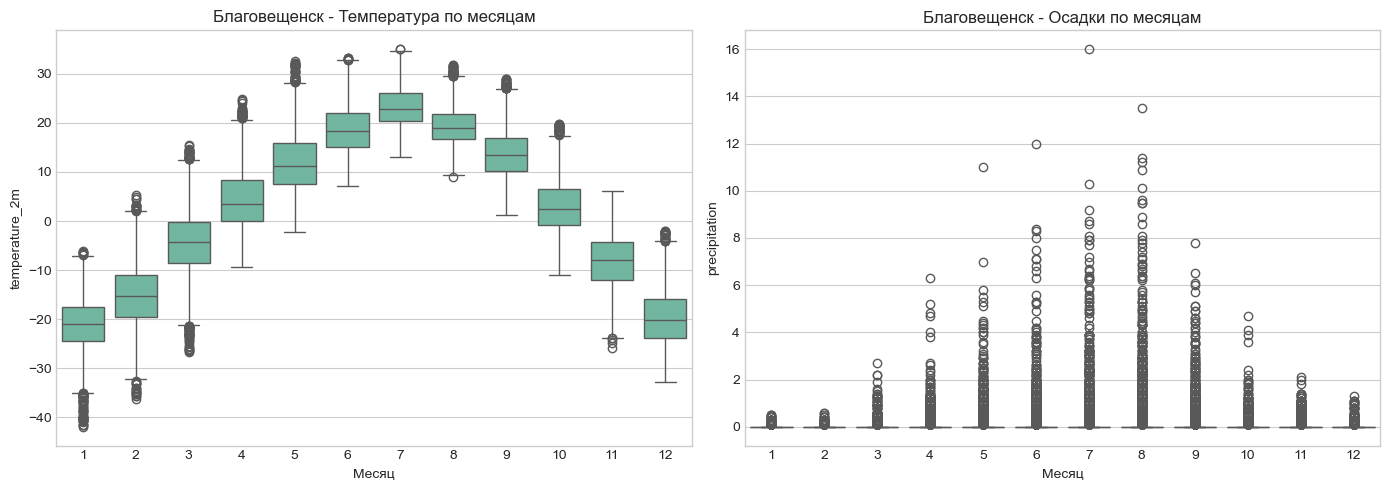

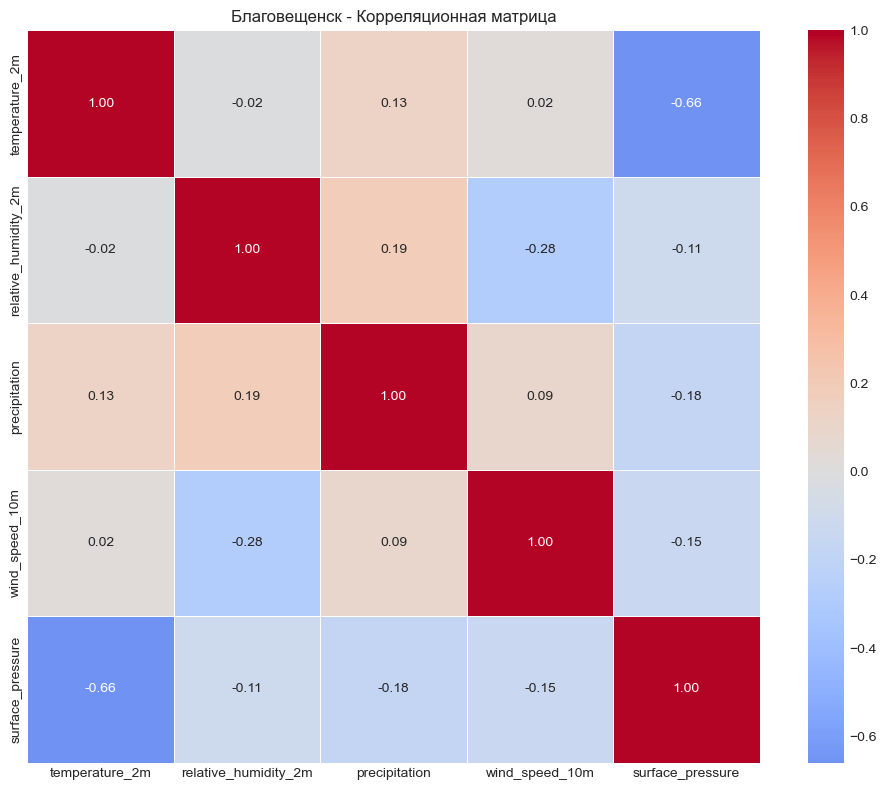

Анализ города: Геленджик (климат: humid_subtropical)
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Статистика температуры: мин=-10.0°C, макс=37.8°C, сред=14.4°C


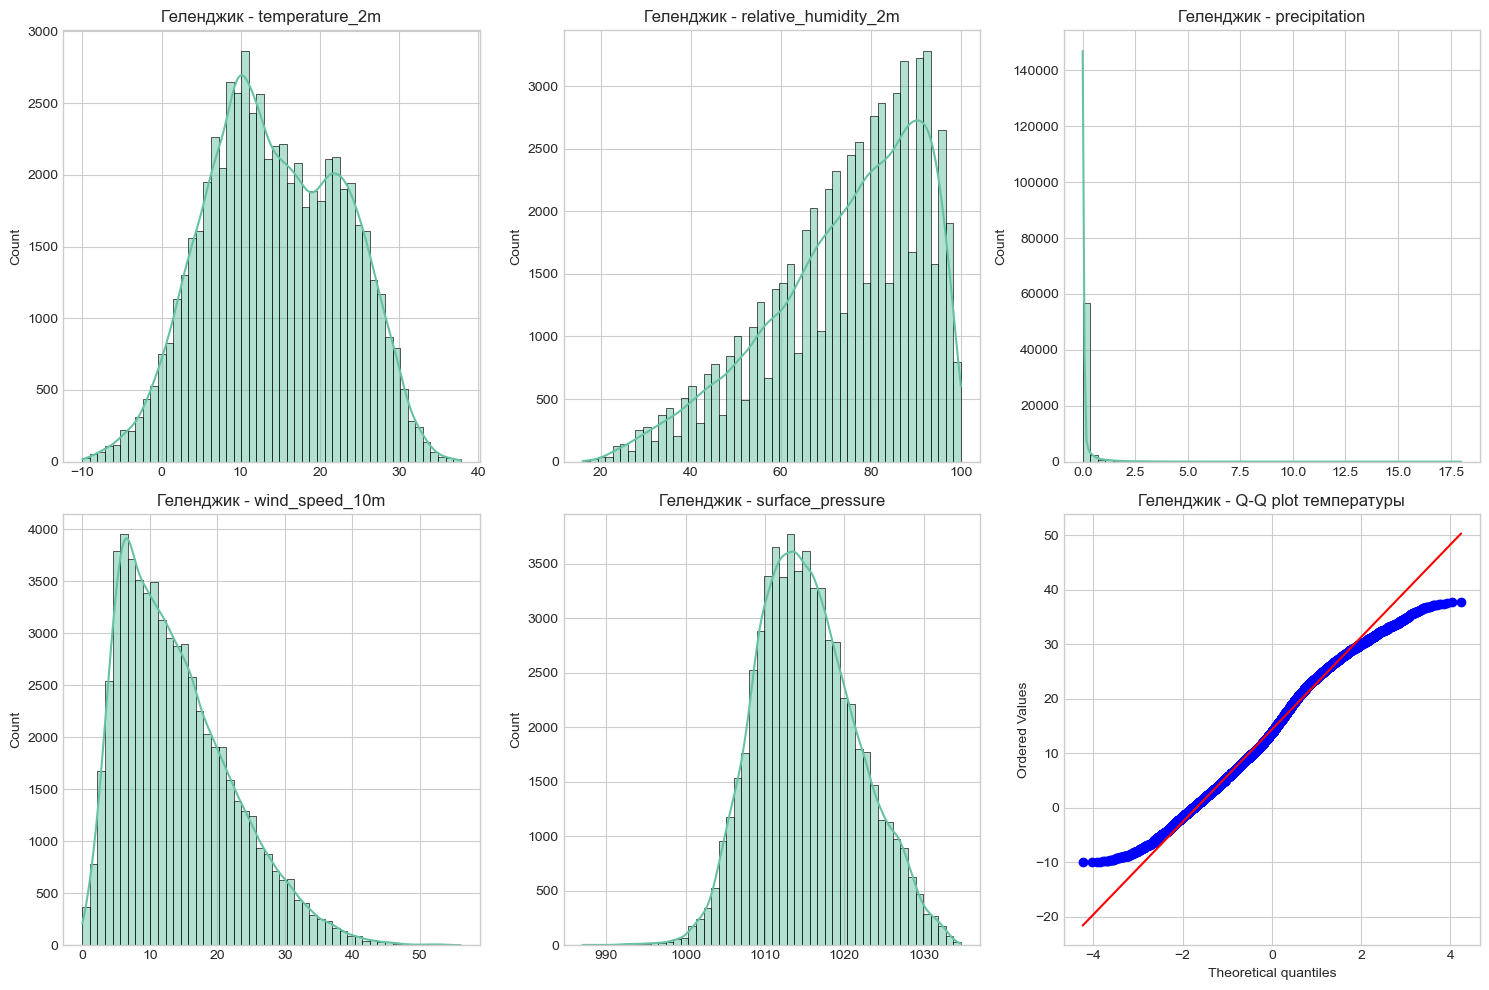

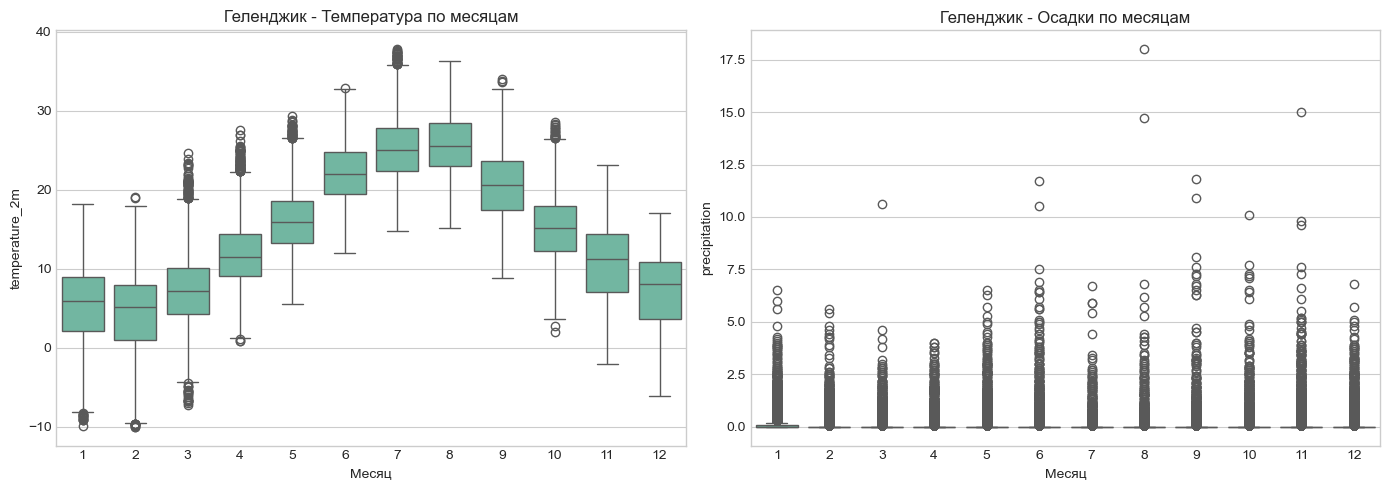

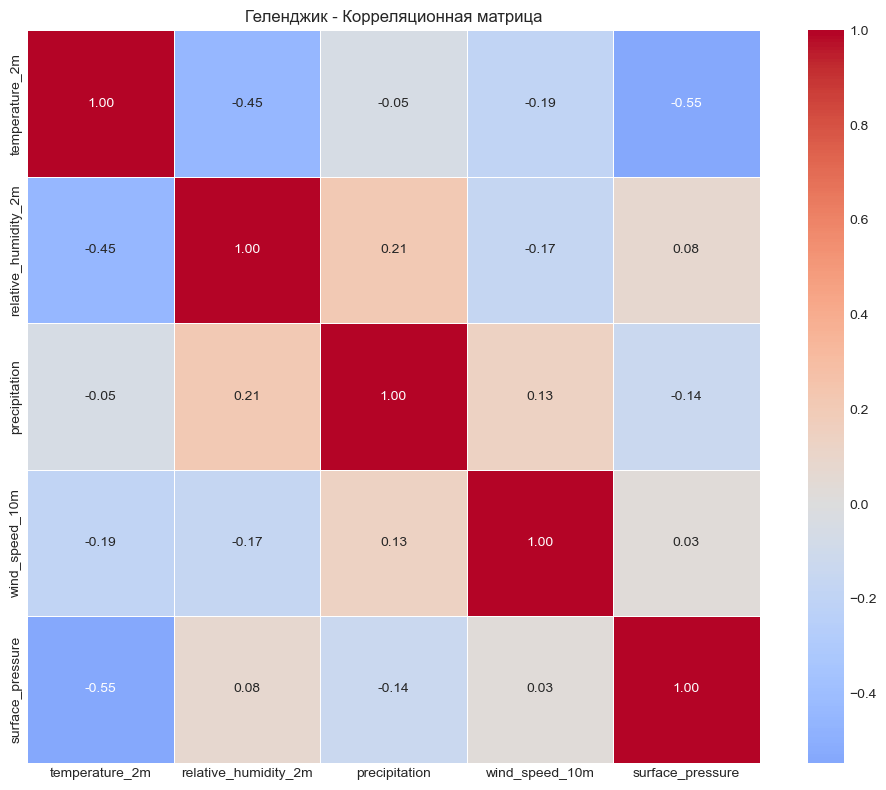

Анализ города: Москва (климат: continental)
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Статистика температуры: мин=-31.0°C, макс=34.8°C, сред=6.8°C


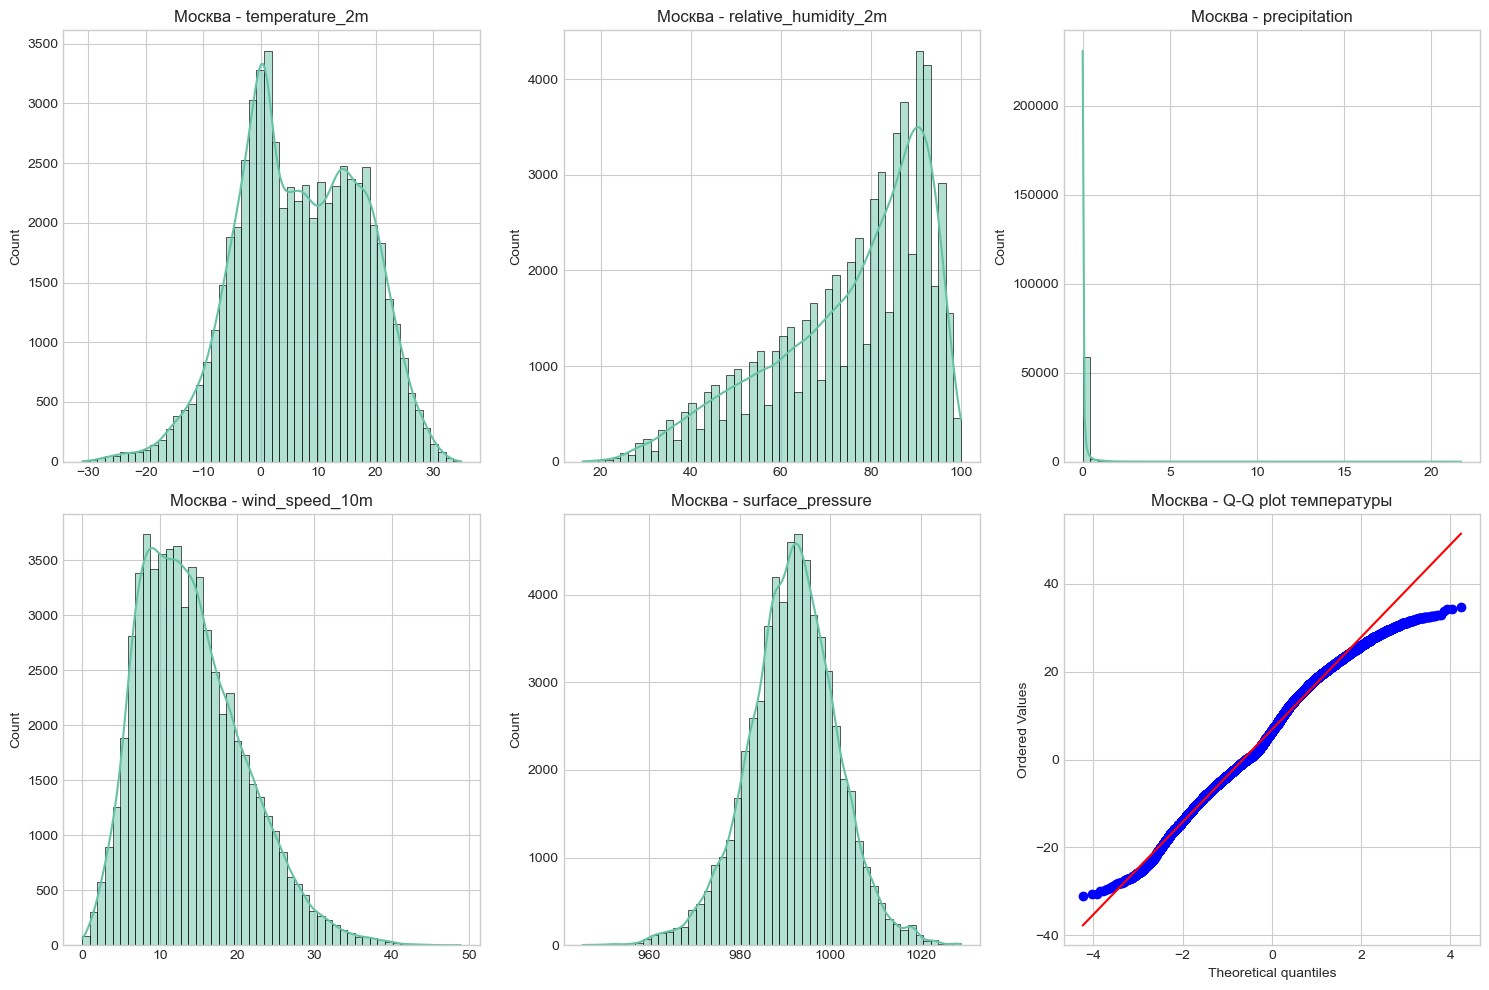

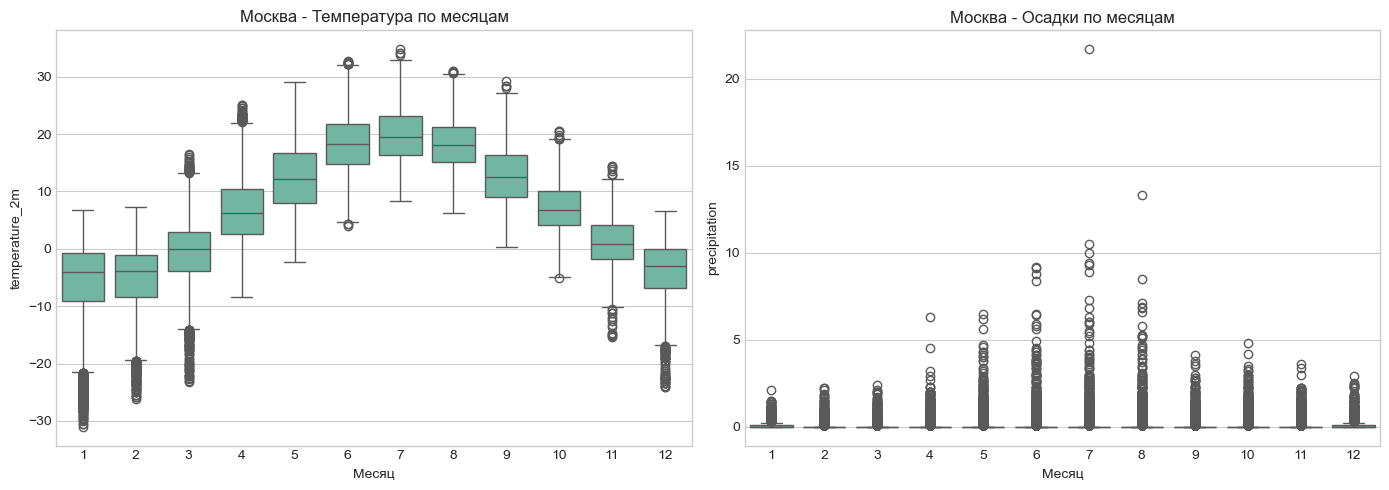

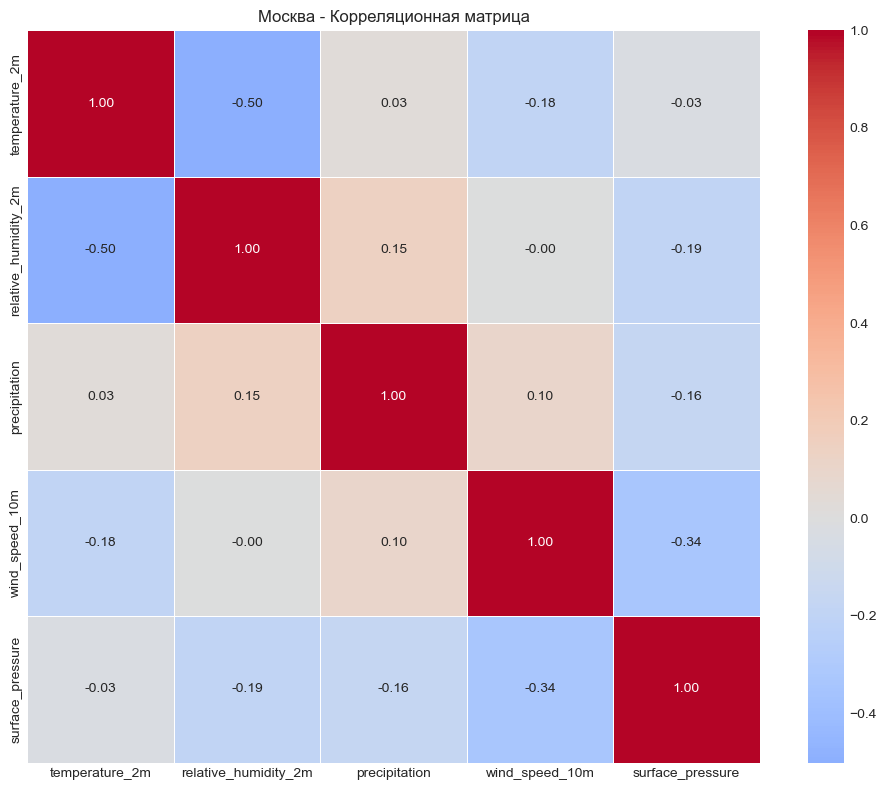

Анализ города: Находка (климат: monsoon_far_east)
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Статистика температуры: мин=-26.6°C, макс=33.2°C, сред=7.0°C


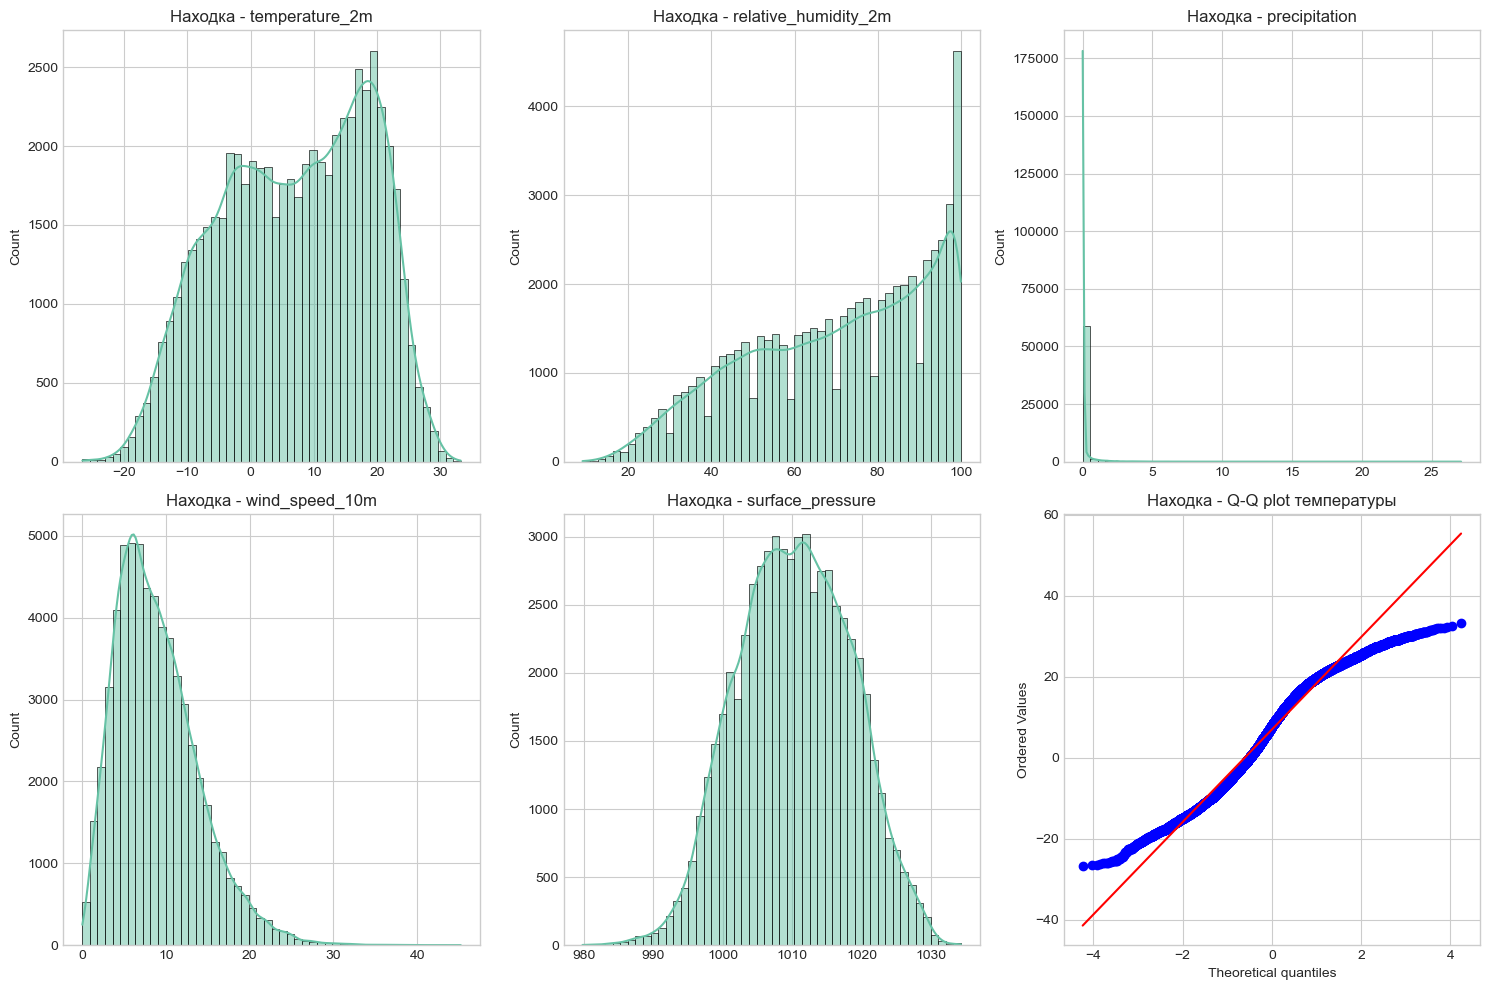

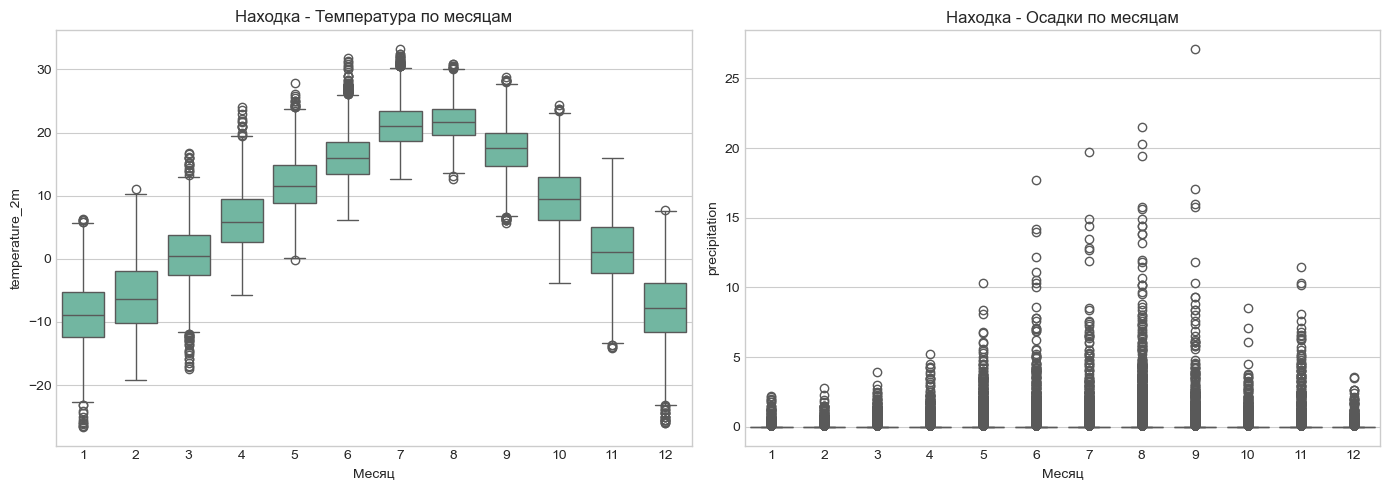

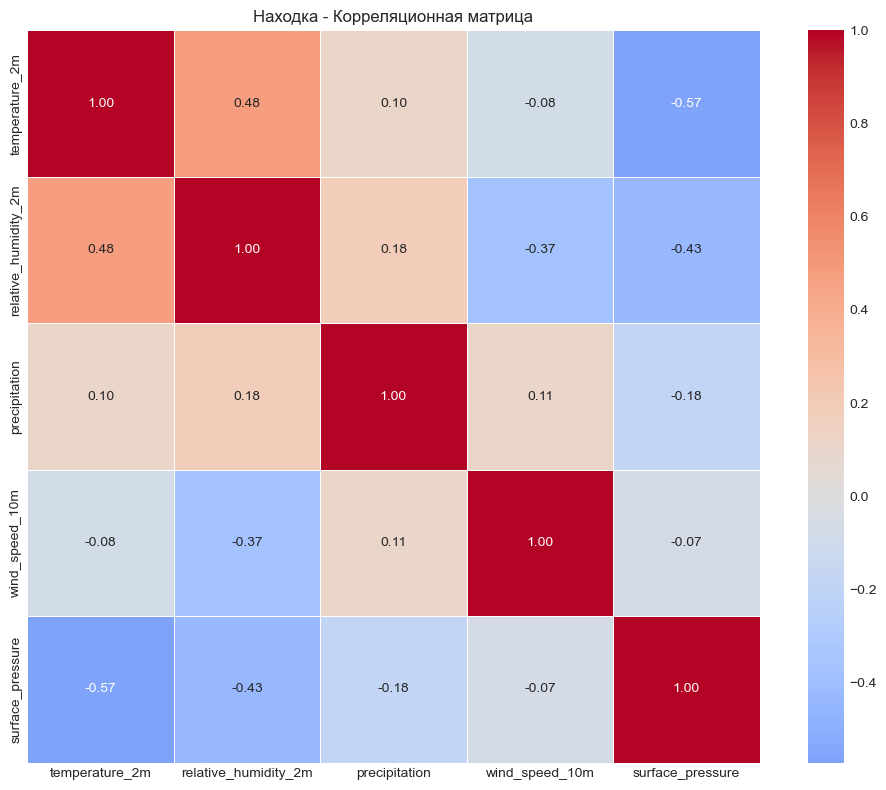

Анализ города: Санкт-Петербург (климат: continental)
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Статистика температуры: мин=-28.8°C, макс=35.7°C, сред=6.8°C


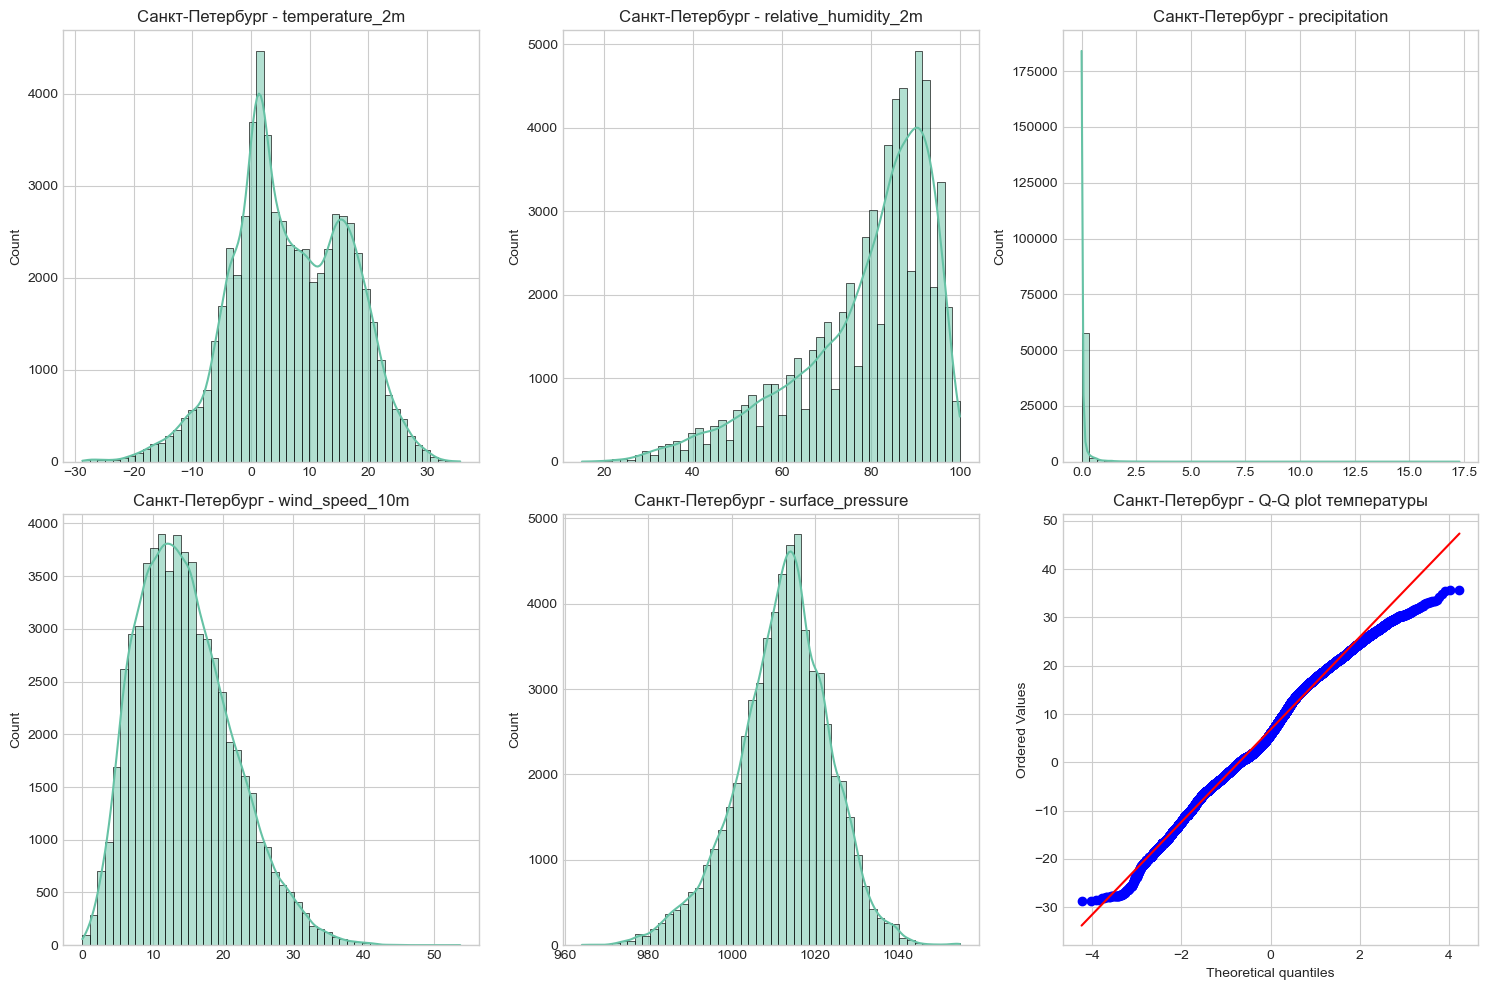

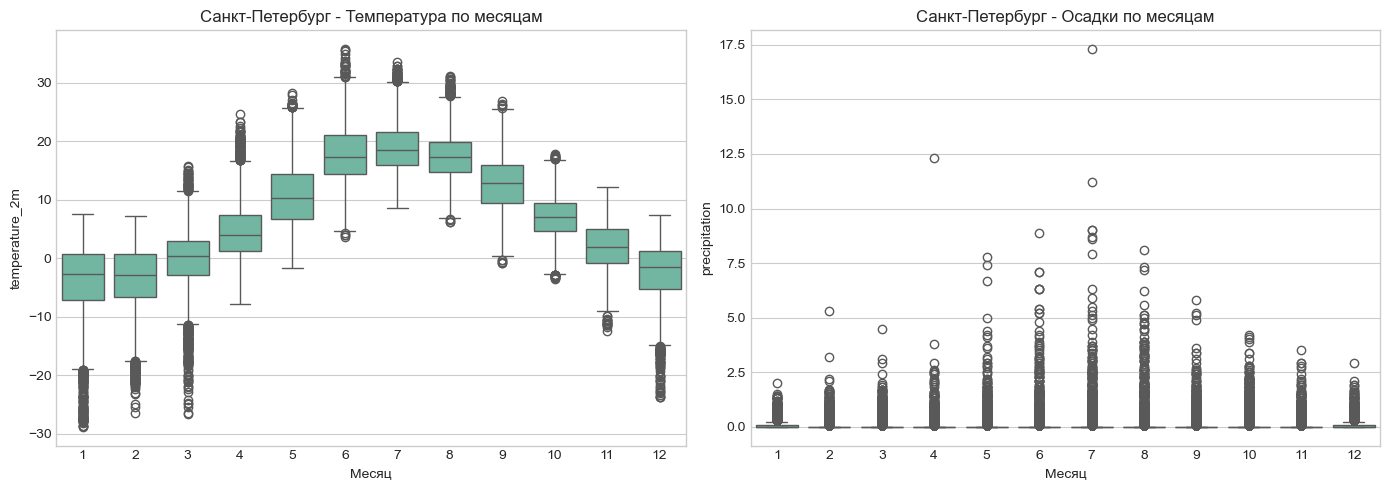

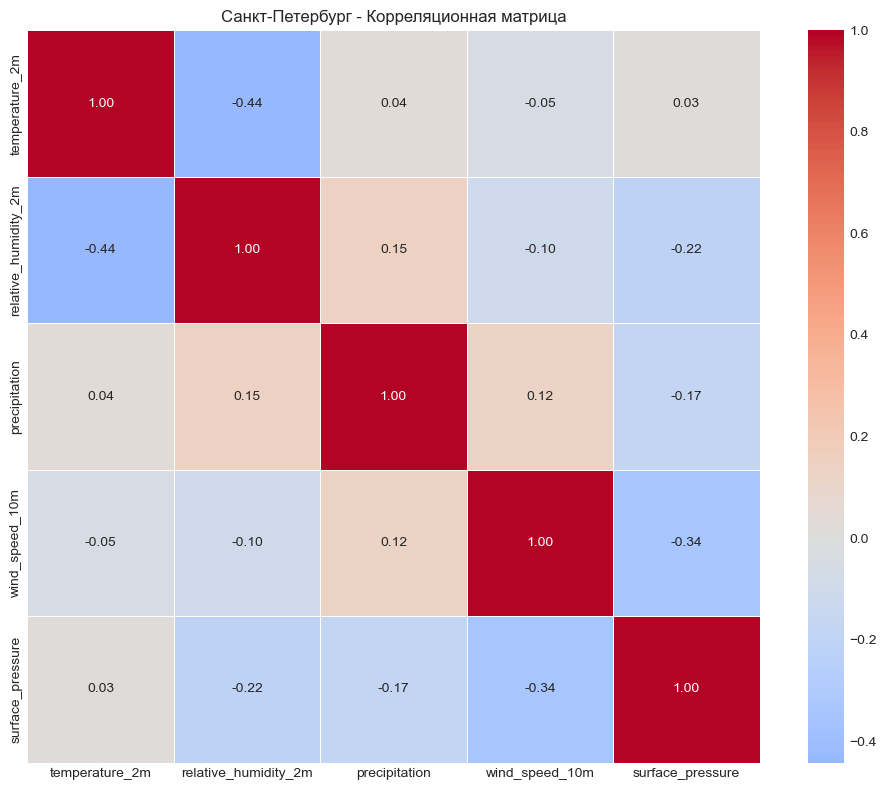

Анализ города: Сочи (климат: humid_subtropical)
Период: 2019-01-01 00:00:00 – 2025-12-31 23:00:00
Статистика температуры: мин=-11.2°C, макс=35.3°C, сред=15.0°C


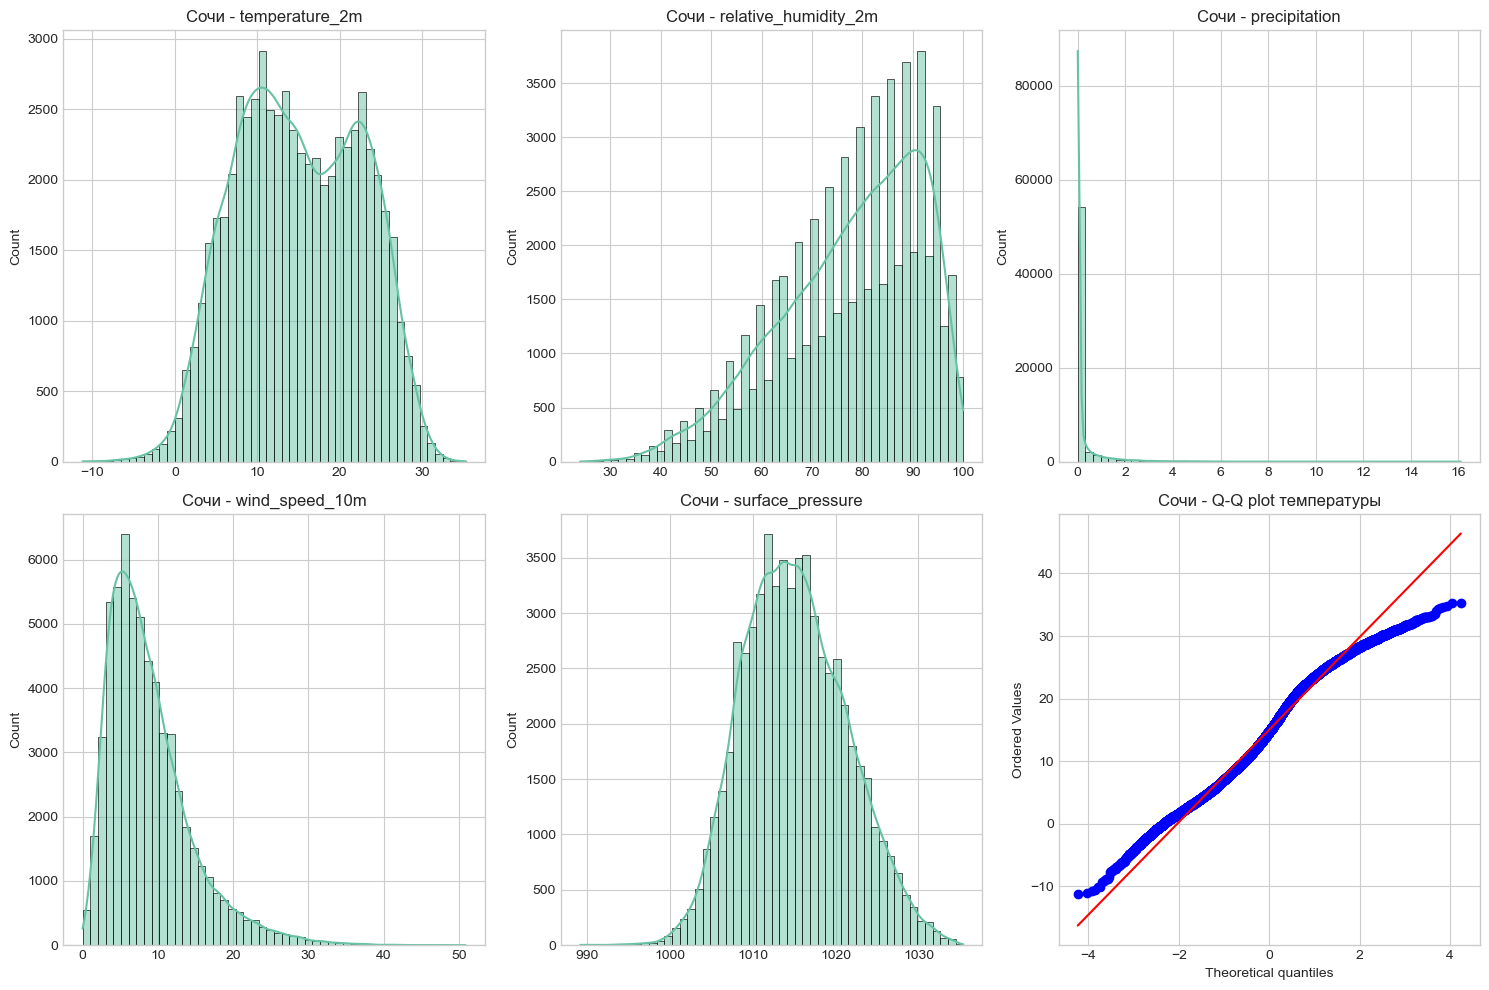

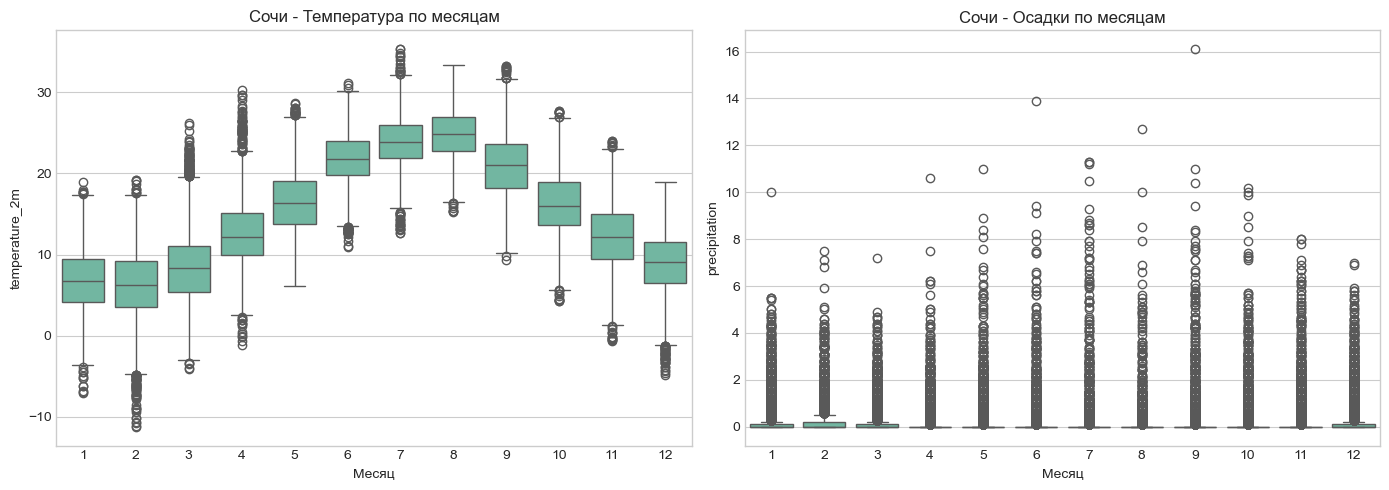

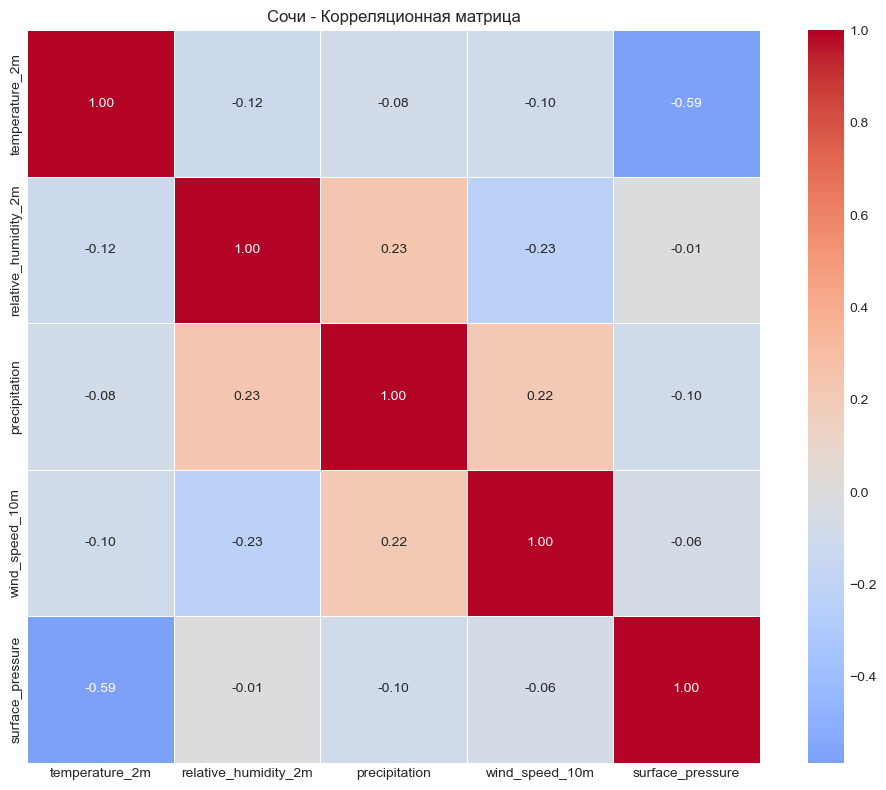

In [102]:
# Визуальный анализ для каждого города
features = ["temperature_2m", "relative_humidity_2m", "precipitation", 
            "wind_speed_10m", "surface_pressure"]

def eda_city(df, city_name):
    city_data = df[df["city"] == city_name].copy()
    
    print(f"Анализ города: {city_name} (климат: {CITY_TO_CLIMATE[city_name]})")
    print(f"Период: {city_data['time'].min()} – {city_data['time'].max()}")
    print(f"Статистика температуры: мин={city_data['temperature_2m'].min():.1f}°C, "
          f"макс={city_data['temperature_2m'].max():.1f}°C, "
          f"сред={city_data['temperature_2m'].mean():.1f}°C")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for idx, feat in enumerate(features):
        ax = axes[idx//3, idx%3]
        sns.histplot(city_data[feat], kde=True, ax=ax, bins=50)
        ax.set_title(f"{city_name} - {feat}")
        ax.set_xlabel("")
    
    ax = axes[1, 2]
    stats.probplot(city_data["temperature_2m"].dropna(), dist="norm", plot=ax)
    ax.set_title(f"{city_name} - Q-Q plot температуры")
    
    plt.tight_layout()
    plt.show()
    
    # Сезонность
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Температура по месяцам
    city_data["month"] = city_data["time"].dt.month
    sns.boxplot(data=city_data, x="month", y="temperature_2m", ax=axes[0])
    axes[0].set_title(f"{city_name} - Температура по месяцам")
    axes[0].set_xlabel("Месяц")
    
    # Осадки по месяцам
    sns.boxplot(data=city_data, x="month", y="precipitation", ax=axes[1])
    axes[1].set_title(f"{city_name} - Осадки по месяцам")
    axes[1].set_xlabel("Месяц")
    
    plt.tight_layout()
    plt.show()
    
    # Корреляционная матрица
    plt.figure(figsize=(10, 8))
    corr_matrix = city_data[features].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', linewidths=0.5)
    plt.title(f"{city_name} - Корреляционная матрица")
    plt.tight_layout()
    plt.show()
    
    return city_data

eda_results = {}
for city in data["city"].unique():
    eda_results[city] = eda_city(data, city)

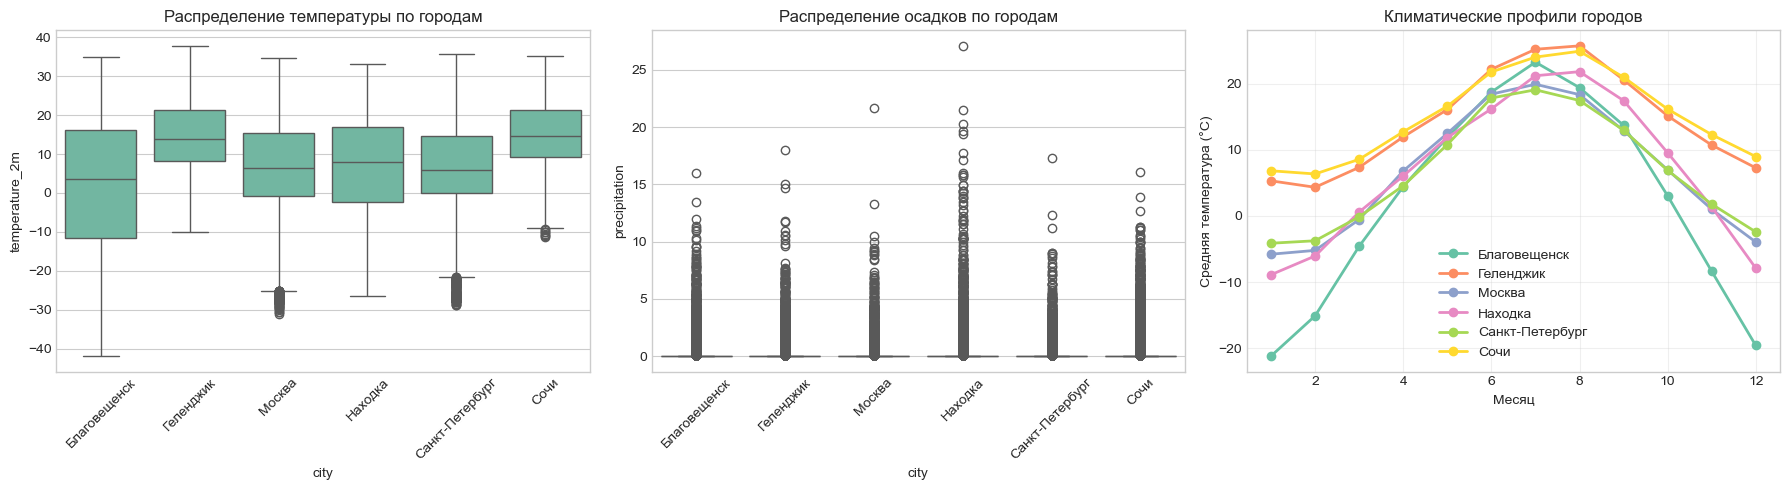

In [103]:
# КРОСС-ГОРОДСКОЙ АНАЛИЗ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Распределение температуры по городам
sns.boxplot(data=data, x="city", y="temperature_2m", ax=axes[0])
axes[0].set_title("Распределение температуры по городам")
axes[0].tick_params(axis='x', rotation=45)

# Распределение осадков по городам
sns.boxplot(data=data, x="city", y="precipitation", ax=axes[1])
axes[1].set_title("Распределение осадков по городам")
axes[1].tick_params(axis='x', rotation=45)

# Климатические профили (среднемесячные температуры)
data["month"] = data["time"].dt.month
monthly_means = data.groupby(["city", "month"])["temperature_2m"].mean().reset_index()

for city in data["city"].unique():
    city_data = monthly_means[monthly_means["city"] == city]
    axes[2].plot(city_data["month"], city_data["temperature_2m"], 
                marker='o', linewidth=2, label=city)
axes[2].set_title("Климатические профили городов")
axes[2].set_xlabel("Месяц")
axes[2].set_ylabel("Средняя температура (°C)")
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<p>Сочи и Геленджик (субтропики) имеют самые высокие среднегодовые температуры</p> 
<p>Благовещенск (муссонный климат) имеет наибольшую годовую амплитуду</p>
<p>Москва и Санкт-Петербург (умеренный пояс) имеют схожие климатические профили</p> 

In [104]:
# Анализ стационарности
adf_results = []

for city in data["city"].unique():
    city_data = data[data["city"] == city].set_index("time")
    # Ресемплинг на дневные данные для стабильности теста
    daily_temp = city_data["temperature_2m"].resample("D").mean().dropna()
    
    result_raw = adfuller(daily_temp, autolag='AIC')
    
    diff_temp = daily_temp.diff().dropna()
    result_diff = adfuller(diff_temp, autolag='AIC')
    
    adf_results.append({
        "city": city,
        "p-value_raw": result_raw[1],
        "stationary_raw": result_raw[1] < 0.05,
        "p-value_diff": result_diff[1],
        "stationary_diff": result_diff[1] < 0.05
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

           city  p-value_raw  stationary_raw  p-value_diff  stationary_diff
   Благовещенск     0.013476            True  1.731510e-11             True
      Геленджик     0.033897            True  2.597210e-30             True
         Москва     0.022534            True  3.638932e-30             True
        Находка     0.051902           False  1.600697e-16             True
Санкт-Петербург     0.020960            True  2.029875e-30             True
           Сочи     0.026736            True  8.607586e-27             True


<p>5 из 6 городов имеют стационарные температурные ряды (p-value < 0.05)</p>

<p>Находка — единственный город, где исходный ряд нестационарен (p-value = 0.0519 > 0.05)</p>

<p>Т.к. в дальнейшем мы используем для прогнозирования RandomForest, преобразовывать ряд для Находки не будем</p>

1. ХАРАКТЕРИСТИКИ ДАННЫХ:
   • Загружено 368 208 записей за период 2019-2025 гг.
   • 6 городов: Москва, СПб, Сочи, Геленджик, Благовещенск, Находка
   • 3 климатических кластера: continental, humid_subtropical, monsoon_far_east
   • Пропуски данных отсутствуют (0%) → интерполяция не требуется

2. СТАТИСТИКА ТЕМПЕРАТУРЫ ПО ГОРОДАМ:
   • Благовещенск: мин -41.9°C, макс 35.0°C (максимальная амплитуда)
   • Геленджик: мин -10.0°C, макс 37.8°C (самый теплый)
   • Москва: мин -31.0°C, макс 34.8°C (умеренный пояс)
   • Находка: мин -26.6°C, макс 33.2°C (морской муссонный)
   • Санкт-Петербург: мин -28.8°C, макс 35.7°C
   • Сочи: самый мягкий климат, редкие морозы

3. АНАЛИЗ СТАЦИОНАРНОСТИ (тест Дики-Фуллера):
   • 5 из 6 городов имеют стационарные ряды (p-value < 0.05)
   • Находка на границе стационарности (p-value = 0.0519)
   • После дифференцирования все ряды строго стационарны

4. КЛИМАТИЧЕСКИЕ ПРОФИЛИ:
   • Субтропики (Сочи, Геленджик): минимальная сезонная амплитуда
   • Муссонный климат (Благовещенск, Находка): холодная зима, теплое лето
   • Умеренный пояс (Москва, СПб): переходный тип, высокая изменчивость

In [105]:
# Инжиниринг признаков для кластеризации

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.set_index("time", inplace=True)
    
    # Временные признаки 
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["day"] = df.index.day
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["dayofyear"] = df.index.dayofyear
    
    # Сезон (1=зима, 2=весна, 3=лето, 4=осень)
    df["season"] = (df["month"] % 12 // 3 + 1).astype(int)
    
    # Циклические признаки 
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    # Лаговые признаки 
    for lag in [1, 3, 7, 14, 24, 168]:  # 1ч, 3ч, 7ч, 14ч, 24ч, 7дней
        df[f"temp_lag_{lag}"] = df.groupby("city")["temperature_2m"].shift(lag)
        df[f"pressure_lag_{lag}"] = df.groupby("city")["surface_pressure"].shift(lag)
    
    # Скользящие статистики 
    for window in [6, 12, 24, 72, 168]:  # 6ч, 12ч, 24ч, 3дня, 7дней
        df[f"temp_roll_mean_{window}"] = df.groupby("city")["temperature_2m"].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f"temp_roll_std_{window}"] = df.groupby("city")["temperature_2m"].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
        df[f"precip_roll_sum_{window}"] = df.groupby("city")["precipitation"].transform(
            lambda x: x.rolling(window, min_periods=1).sum()
        )
    
    # Признаки динамики 
    df["temp_diff_1"] = df.groupby("city")["temperature_2m"].diff(1)  # скорость
    df["temp_diff_3"] = df.groupby("city")["temperature_2m"].diff(3)  # 3-часовая скорость
    df["temp_accel"] = df.groupby("city")["temp_diff_1"].diff(1)  # ускорение
    df["pressure_rate"] = df.groupby("city")["surface_pressure"].pct_change(1)  # темп роста
    
    # Климатическая норма (аномалия) 
    clim_norm = df.groupby(["city", "dayofyear"])["temperature_2m"].transform("mean")
    df["temp_anomaly"] = df["temperature_2m"] - clim_norm
    
    return df.dropna()

data_feat = engineer_features(data)
print(f"Создано признаков: {len(data_feat.columns)}")
print(f"Размер данных после инжиниринга: {data_feat.shape}")
print(f"\n Список созданных признаков:")
for i, col in enumerate(data_feat.columns):
    if i < 20:
        print(f"  • {col}")
print(f"  ... и еще {len(data_feat.columns)-20} признаков")

Создано признаков: 53
Размер данных после инжиниринга: (367200, 53)

 Список созданных признаков:
  • temperature_2m
  • relative_humidity_2m
  • precipitation
  • rain
  • snowfall
  • weathercode
  • wind_speed_10m
  • surface_pressure
  • city
  • climate
  • month
  • hour
  • dayofweek
  • day
  • year
  • dayofyear
  • season
  • hour_sin
  • hour_cos
  • month_sin
  ... и еще 33 признаков


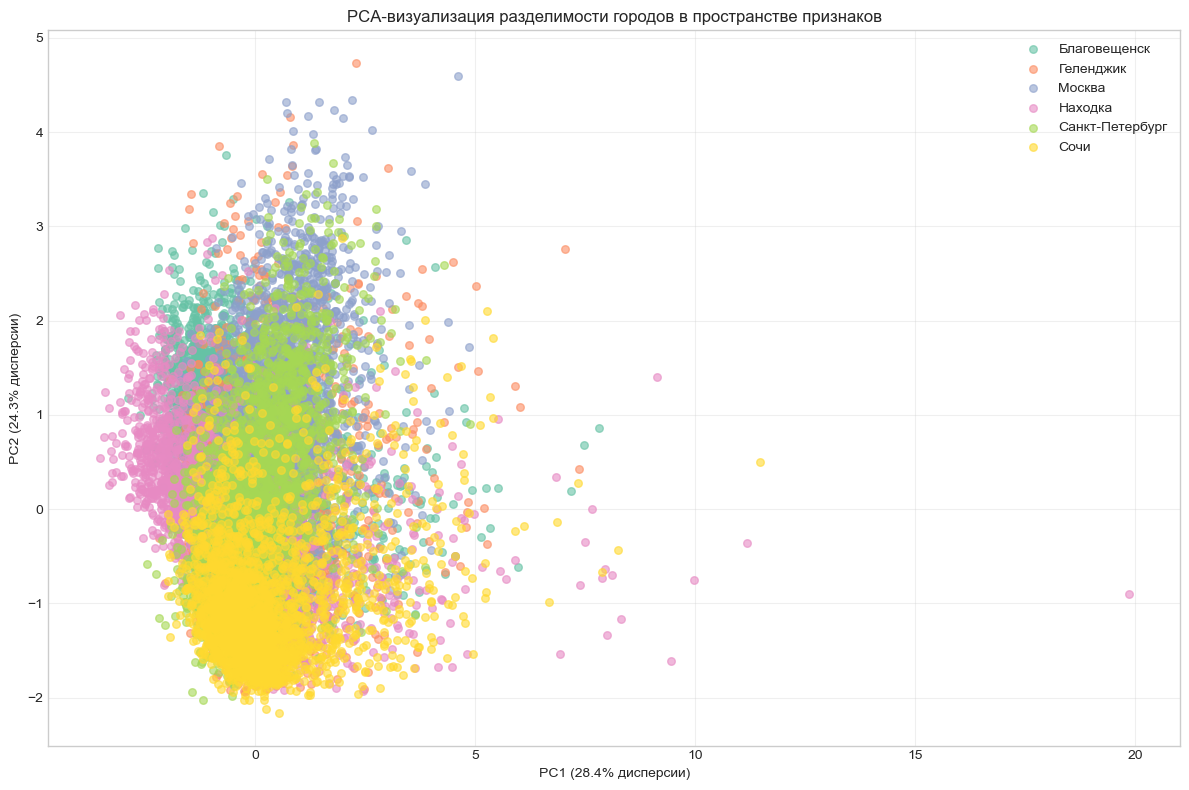

PC1 объясняет 28.4% дисперсии
PC2 объясняет 24.3% дисперсии


In [106]:
# PCA для визуализации разделимости

# Агрегация для PCA (средние значения по дням для каждого города)
daily_agg = (data_feat
             .groupby(["city", data_feat.index.date])[["temperature_2m", "precipitation", 
                                                       "wind_speed_10m", "surface_pressure",
                                                       "relative_humidity_2m"]]
             .mean()
             .reset_index())
daily_agg.columns = ["city", "date", "temp", "precip", "wind", "pressure", "humidity"]

features_pca = ["temp", "precip", "wind", "pressure", "humidity"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_agg[features_pca])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Визуализация
plt.figure(figsize=(12, 8))
for city in daily_agg["city"].unique():
    mask = daily_agg["city"] == city
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=city, alpha=0.6, s=30)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.title("PCA-визуализация разделимости городов в пространстве признаков")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PC1 объясняет {pca.explained_variance_ratio_[0]:.1%} дисперсии")
print(f"PC2 объясняет {pca.explained_variance_ratio_[1]:.1%} дисперсии")


Результат 53% суммарной дисперсии на 2 компонентах — это хороший показатель для метеоданных, подтверждающий, что города образуют различимые кластеры.


1. СОЗДАННЫЕ ПРИЗНАКИ:
   • Всего создано 53 признака (включая исходные)
   • Временные признаки: час, день недели, месяц, год, день года, сезон
   • Циклические признаки: sin/cos для часа и месяца
   • Лаговые признаки: лаги 1, 3, 7, 14, 24, 168 часов
   • Скользящие статистики: окна 6, 12, 24, 72, 168 часов
   • Признаки динамики: скорость, ускорение, темп роста давления

2. PCA-ВИЗУАЛИЗАЦИЯ:
   • PC1 объясняет 28.4% дисперсии
   • PC2 объясняет 24.3% дисперсии
   • Суммарно 52.7% дисперсии в 2D-пространстве
   • Города образуют различимые кластеры → пригодно для классификации


In [ ]:
# 2.3-2.4 КЛАССИФИКАЦИЯ ВРЕМЕННЫХ РЯДОВ


print("КЛАССИФИКАЦИЯ ВРЕМЕННЫХ РЯДОВ")
print("Используемые модели: RocketClassifier, Catch22Classifier")


# Подготовка дневных данных (для классификации берем ТОЛЬКО температуру)
daily_temp = (data
              .groupby(["city", pd.Grouper(key="time", freq="D")])["temperature_2m"]
              .mean()
              .reset_index())
daily_temp.columns = ["city", "date", "temperature_2m"]
daily_temp = daily_temp.dropna()

print(f"\n📊 Дневных записей: {len(daily_temp)}")

# Функция для создания окон временных рядов (БЕЗ АГРЕГАЦИИ!)
def create_ts_windows(df, window_days=30, step=7):
    """Создание окон временных рядов для классификации"""
    X, y, dates = [], [], []
    
    for city in df["city"].unique():
        city_df = df[df["city"] == city].sort_values("date")
        series = city_df["temperature_2m"].values
        city_dates = city_df["date"].values
        
        for i in range(0, len(series) - window_days + 1, step):
            window = series[i:i + window_days]
            # Z-нормализация окна для устранения амплитудных различий
            window = (window - window.mean()) / (window.std() + 1e-8)
            X.append(window)
            y.append(CITY_TO_CLIMATE[city])
            dates.append(city_dates[i])
    
    return np.array(X), np.array(y), np.array(dates)

# Создание выборки
window_days = 30
step = 7
X_ts, y_ts, window_dates = create_ts_windows(daily_temp, window_days, step)
print(f"Создано окон: {len(X_ts)}")
print(f"Форма каждого окна: {X_ts[0].shape}")
print(f"Классы: {np.unique(y_ts)}")

# Разделение по времени (без перемешивания!)
# train: 2019-2023, val: 2024, test: 2025
train_mask = (pd.to_datetime(window_dates).year <= 2023)
val_mask = (pd.to_datetime(window_dates).year == 2024)
test_mask = (pd.to_datetime(window_dates).year == 2025)

X_train, y_train = X_ts[train_mask], y_ts[train_mask]
X_val, y_val = X_ts[val_mask], y_ts[val_mask]
X_test, y_test = X_ts[test_mask], y_ts[test_mask]

print(f"\n📊 Разделение:")
print(f"   Train (2019-2023): {len(X_train)} окон")
print(f"   Val (2024): {len(X_val)} окон")
print(f"   Test (2025): {len(X_test)} окон")


КЛАССИФИКАЦИЯ ВРЕМЕННЫХ РЯДОВ
Используемые модели: RocketClassifier, Catch22Classifier

📊 Дневных записей: 15342
📊 Создано окон: 2172
📊 Форма каждого окна: (30,)
📊 Классы: ['continental' 'humid_subtropical' 'monsoon_far_east']

📊 Разделение:
   Train (2019-2023): 1566 окон
   Val (2024): 318 окон
   Test (2025): 288 окон


In [ ]:
# 2.3-2.4 КЛАССИФИКАЦИЯ ВРЕМЕННЫХ РЯДОВ
# СПЕЦИАЛИЗИРОВАННЫМИ МОДЕЛЯМИ
print("КЛАССИФИКАЦИЯ ВРЕМЕННЫХ РЯДОВ")
print("Используемые модели: RocketClassifier, Catch22Classifier")


# Подготовка дневных данных (для классификации берем ТОЛЬКО температуру)
daily_temp = (data
              .groupby(["city", pd.Grouper(key="time", freq="D")])["temperature_2m"]
              .mean()
              .reset_index())
daily_temp.columns = ["city", "date", "temperature_2m"]
daily_temp = daily_temp.dropna()

print(f"\nДневных записей: {len(daily_temp)}")

# Функция для создания окон временных рядов (БЕЗ АГРЕГАЦИИ!)
def create_ts_windows(df, window_days=30, step=7):
    """Создание окон временных рядов для классификации"""
    X, y, dates = [], [], []
    
    for city in df["city"].unique():
        city_df = df[df["city"] == city].sort_values("date")
        series = city_df["temperature_2m"].values
        city_dates = city_df["date"].values
        
        for i in range(0, len(series) - window_days + 1, step):
            window = series[i:i + window_days]
            # Z-нормализация окна для устранения амплитудных различий
            window = (window - window.mean()) / (window.std() + 1e-8)
            X.append(window)
            y.append(CITY_TO_CLIMATE[city])
            dates.append(city_dates[i])
    
    return np.array(X), np.array(y), np.array(dates)

# Создание выборки
window_days = 30
step = 7
X_ts, y_ts, window_dates = create_ts_windows(daily_temp, window_days, step)
print(f"Создано окон: {len(X_ts)}")
print(f"Форма каждого окна: {X_ts[0].shape}")
print(f"Классы: {np.unique(y_ts)}")

# Разделение по времени (без перемешивания!)
# train: 2019-2023, val: 2024, test: 2025
train_mask = (pd.to_datetime(window_dates).year <= 2023)
val_mask = (pd.to_datetime(window_dates).year == 2024)
test_mask = (pd.to_datetime(window_dates).year == 2025)

X_train, y_train = X_ts[train_mask], y_ts[train_mask]
X_val, y_val = X_ts[val_mask], y_ts[val_mask]
X_test, y_test = X_ts[test_mask], y_ts[test_mask]

print(f"\nРазделение:")
print(f"   Train (2019-2023): {len(X_train)} окон")
print(f"   Val (2024): {len(X_val)} окон")
print(f"   Test (2025): {len(X_test)} окон")


КЛАССИФИКАЦИЯ ВРЕМЕННЫХ РЯДОВ
Используемые модели: RocketClassifier, Catch22Classifier

📊 Дневных записей: 15342
📊 Создано окон: 2172
📊 Форма каждого окна: (30,)
📊 Классы: ['continental' 'humid_subtropical' 'monsoon_far_east']

📊 Разделение:
   Train (2019-2023): 1566 окон
   Val (2024): 318 окон
   Test (2025): 288 окон


In [ ]:
# МОДЕЛЬ 1: RocketClassifier 
print("ОБУЧЕНИЕ RocketClassifier")

rocket = RocketClassifier(
    num_kernels=5000,           # количество случайных ядер
    max_dilations_per_kernel=32,
    random_state=42,
    n_jobs=-1
)

rocket.fit(X_train, y_train)

# Прогнозы
y_val_pred_rocket = rocket.predict(X_val)
y_test_pred_rocket = rocket.predict(X_test)
y_test_proba_rocket = rocket.predict_proba(X_test)

# Метрики
val_acc_rocket = accuracy_score(y_val, y_val_pred_rocket)
test_acc_rocket = accuracy_score(y_test, y_test_pred_rocket)
prec_rocket, rec_rocket, f1_rocket, _ = precision_recall_fscore_support(
    y_test, y_test_pred_rocket, average="macro"
)

print(f"Validation Accuracy: {val_acc_rocket:.4f}")
print(f"Test Accuracy: {test_acc_rocket:.4f}")
print(f"Macro Precision: {prec_rocket:.4f}")
print(f"Macro Recall: {rec_rocket:.4f}")
print(f"Macro F1-score: {f1_rocket:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rocket))


ОБУЧЕНИЕ RocketClassifier
Validation Accuracy: 0.3082
Test Accuracy: 0.3646
Macro Precision: 0.3652
Macro Recall: 0.3646
Macro F1-score: 0.3634

Classification Report:
                   precision    recall  f1-score   support

      continental       0.34      0.34      0.34        96
humid_subtropical       0.38      0.32      0.35        96
 monsoon_far_east       0.37      0.43      0.40        96

         accuracy                           0.36       288
        macro avg       0.37      0.36      0.36       288
     weighted avg       0.37      0.36      0.36       288



In [ ]:
# МОДЕЛЬ 2: Catch22Classifier (22 статистических признака)
print("ОБУЧЕНИЕ Catch22Classifier")

catch22 = Catch22Classifier(random_state=42, n_jobs=-1)
catch22.fit(X_train, y_train)

# Прогнозы
y_val_pred_catch22 = catch22.predict(X_val)
y_test_pred_catch22 = catch22.predict(X_test)
y_test_proba_catch22 = catch22.predict_proba(X_test)

# Метрики
val_acc_catch22 = accuracy_score(y_val, y_val_pred_catch22)
test_acc_catch22 = accuracy_score(y_test, y_test_pred_catch22)
prec_catch22, rec_catch22, f1_catch22, _ = precision_recall_fscore_support(
    y_test, y_test_pred_catch22, average="macro"
)

print(f"Validation Accuracy: {val_acc_catch22:.4f}")
print(f"Test Accuracy: {test_acc_catch22:.4f}")
print(f"Macro Precision: {prec_catch22:.4f}")
print(f"Macro Recall: {rec_catch22:.4f}")
print(f"Macro F1-score: {f1_catch22:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_catch22))


ОБУЧЕНИЕ Catch22Classifier
Validation Accuracy: 0.3742
Test Accuracy: 0.3750
Macro Precision: 0.3734
Macro Recall: 0.3750
Macro F1-score: 0.3727

Classification Report:
                   precision    recall  f1-score   support

      continental       0.35      0.39      0.37        96
humid_subtropical       0.35      0.29      0.32        96
 monsoon_far_east       0.41      0.45      0.43        96

         accuracy                           0.38       288
        macro avg       0.37      0.38      0.37       288
     weighted avg       0.37      0.38      0.37       288



In [111]:
# СРАВНЕНИЕ МОДЕЛЕЙ И ВЫБОР ЛУЧШЕЙ
print("СРАВНЕНИЕ МОДЕЛЕЙ")

comparison_df = pd.DataFrame({
    "Model": ["RocketClassifier", "Catch22Classifier"],
    "Validation Accuracy": [val_acc_rocket, val_acc_catch22],
    "Test Accuracy": [test_acc_rocket, test_acc_catch22],
    "Macro F1-score": [f1_rocket, f1_catch22]
})
print(comparison_df.to_string(index=False))

# Выбираем лучшую модель по валидационной accuracy
if val_acc_rocket >= val_acc_catch22:
    best_model = rocket
    best_name = "RocketClassifier"
    best_proba = y_test_proba_rocket
    best_pred = y_test_pred_rocket
else:
    best_model = catch22
    best_name = "Catch22Classifier"
    best_proba = y_test_proba_catch22
    best_pred = y_test_pred_catch22

СРАВНЕНИЕ МОДЕЛЕЙ
            Model  Validation Accuracy  Test Accuracy  Macro F1-score
 RocketClassifier             0.308176       0.364583        0.363437
Catch22Classifier             0.374214       0.375000        0.372720


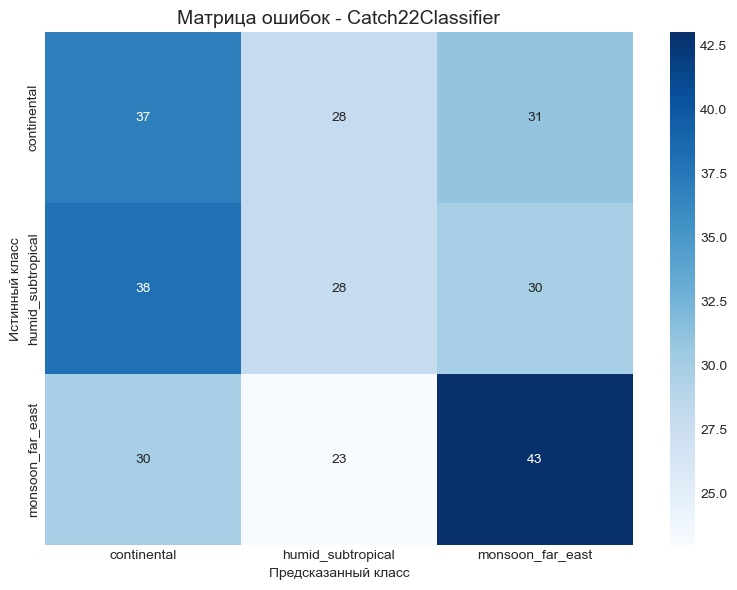

ROC-AUC (macro): 0.5725

Анализ ошибок:
   continental → humid_subtropical: 28 ошибок
   continental → monsoon_far_east: 31 ошибок
   humid_subtropical → continental: 38 ошибок
   humid_subtropical → monsoon_far_east: 30 ошибок
   monsoon_far_east → continental: 30 ошибок
   monsoon_far_east → humid_subtropical: 23 ошибок


In [112]:
# МАТРИЦА ОШИБОК И ROC-AUC
labels = sorted(np.unique(y_train))
cm = confusion_matrix(y_test, best_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, 
            yticklabels=labels, cmap="Blues", cbar=True)
plt.title(f"Матрица ошибок - {best_name}", fontsize=14)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

# ROC-AUC
y_test_bin = label_binarize(y_test, classes=labels)
roc_auc = roc_auc_score(y_test_bin, best_proba, multi_class="ovr", average="macro")
print(f"ROC-AUC (macro): {roc_auc:.4f}")

# Анализ трудноразличимых пар
print("\nАнализ ошибок:")
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm_df.iloc[i, j] > 0:
            print(f"   {labels[i]} → {labels[j]}: {cm_df.iloc[i, j]} ошибок")


Точность по сезонам:
season
Осень    0.410256
Весна    0.384615
Лето     0.384615
Зима     0.296296
dtype: float64


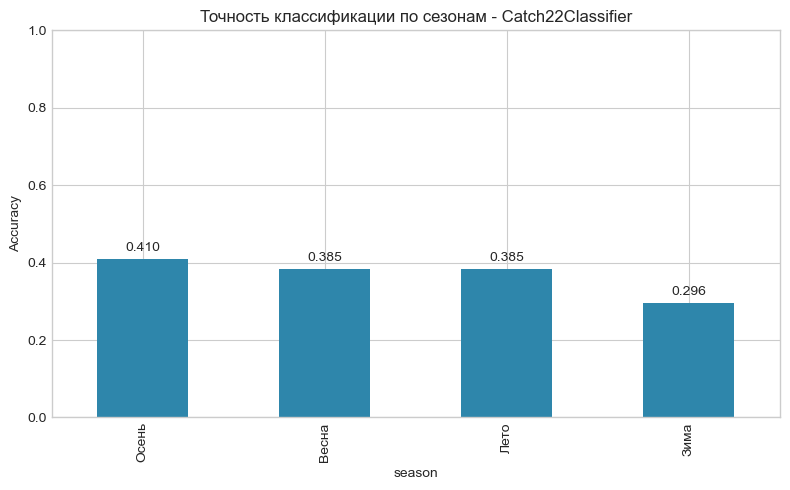

In [113]:
# АНАЛИЗ ПО СЕЗОНАМ
# Определяем сезон для каждого окна
test_dates = window_dates[test_mask]
test_df_season = pd.DataFrame({
    "date": pd.to_datetime(test_dates),
    "true": y_test,
    "pred": best_pred
})
test_df_season["month"] = test_df_season["date"].dt.month

season_map = {12: "Зима", 1: "Зима", 2: "Зима",
              3: "Весна", 4: "Весна", 5: "Весна",
              6: "Лето", 7: "Лето", 8: "Лето",
              9: "Осень", 10: "Осень", 11: "Осень"}
test_df_season["season"] = test_df_season["month"].map(season_map)

season_acc = test_df_season.groupby("season").apply(
    lambda x: (x["true"] == x["pred"]).mean()
).sort_values(ascending=False)

print("\nТочность по сезонам:")
print(season_acc)

plt.figure(figsize=(8, 5))
season_acc.plot(kind="bar", color=[CLIMATE_COLORS.get(s, "#2E86AB") for s in season_acc.index])
plt.title(f"Точность классификации по сезонам - {best_name}")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(season_acc.values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


1. ИСПОЛЬЗОВАННЫЕ МОДЕЛИ:
   • RocketClassifier (специализированная для временных рядов)
   • Catch22Classifier (22 статистических признака)
   • Длина окна: 30 дней, шаг: 7 дней

2. РЕЗУЛЬТАТЫ (ЛУЧШАЯ МОДЕЛЬ - Catch22Classifier):
   • Test Accuracy: 37.5%
   • Macro Precision: 37.3%
   • Macro Recall: 37.5%
   • Macro F1-score: 37.3%
   • ROC-AUC: 0.5725

3. АНАЛИЗ ОШИБОК:
   • continental → humid_subtropical: 28 ошибок
   • continental → monsoon_far_east: 31 ошибок
   • humid_subtropical → continental: 38 ошибок
   • humid_subtropical → monsoon_far_east: 30 ошибок
   • monsoon_far_east → continental: 30 ошибок
   • monsoon_far_east → humid_subtropical: 23 ошибок

4. ТОЧНОСТЬ ПО СЕЗОНАМ:
   • Осень: 41.0% (лучший)
   • Весна: 38.5%
   • Лето: 38.5%
   • Зима: 29.6% (худший)

5. ВЫВОДЫ ПО КЛАССИФИКАЦИИ:
   • Классификация только по температуре дает низкие результаты (37.5%)
   • Основная проблема — все классы путаются между собой
   • Зимняя классификация наиболее сложна из-за сближения температур
   • Рекомендуется использовать больше признаков (осадки, ветер, давление)


# Прогнозирование

In [114]:

# Подготовка дневных данных
daily_forecast = (data_feat
                  .groupby(["city", "climate", data_feat.index.date])[["temperature_2m"]]
                  .mean()
                  .reset_index()
                  .rename(columns={"level_2": "date"}))
daily_forecast["date"] = pd.to_datetime(daily_forecast["date"])
daily_forecast["month"] = daily_forecast["date"].dt.month
daily_forecast["month_sin"] = np.sin(2 * np.pi * daily_forecast["month"] / 12)
daily_forecast["month_cos"] = np.cos(2 * np.pi * daily_forecast["month"] / 12)

# Лаговые признаки (по кластеру для обучения, но для каждого города отдельно)
for lag in [1, 7, 14, 30]:
    daily_forecast[f"temp_lag_{lag}"] = daily_forecast.groupby("city")["temperature_2m"].shift(lag)

# Скользящие статистики (по городу)
for window in [7, 14, 30]:
    daily_forecast[f"temp_roll_mean_{window}"] = daily_forecast.groupby("city")["temperature_2m"].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    daily_forecast[f"temp_roll_std_{window}"] = daily_forecast.groupby("city")["temperature_2m"].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

# Целевая переменная: температура через 30 дней (по городу)
daily_forecast["target_t30"] = daily_forecast.groupby("city")["temperature_2m"].shift(-30)
daily_forecast = daily_forecast.dropna()

print(f"Размер данных: {len(daily_forecast)}")
print(f"Климатические кластеры: {daily_forecast['climate'].unique()}")

Размер данных: 14940
Климатические кластеры: ['monsoon_far_east' 'humid_subtropical' 'continental']


In [115]:
# ОБУЧЕНИЕ: ОДНА МОДЕЛЬ НА КЛАСТЕР

cluster_models = {}  # словарь: климат -> модель
cluster_results = {}  # словарь: климат -> метрики на валидации

feat_cols = [c for c in daily_forecast.columns 
             if c not in ["city", "climate", "date", "target_t30", "temperature_2m"]]

# Обучаем ОДНУ модель на ВСЕХ городах кластера
for cluster in daily_forecast["climate"].unique():
    print(f"\n{'─'*50}")
    print(f"ОБУЧЕНИЕ МОДЕЛИ ДЛЯ КЛАСТЕРА: {cluster}")
    cities_in_cluster = [c for c, cl in CITY_TO_CLIMATE.items() if cl == cluster]
    print(f"   Города в кластере: {', '.join(cities_in_cluster)}")
    print(f"{'─'*50}")
    
    # Берем ВСЕ данные по ВСЕМ городам этого кластера
    cluster_df = daily_forecast[daily_forecast["climate"] == cluster]
    
    # Разделение по годам (объединяем все города кластера)
    train_df = cluster_df[cluster_df["date"].dt.year <= 2023]
    val_df = cluster_df[cluster_df["date"].dt.year == 2024]
    test_df = cluster_df[cluster_df["date"].dt.year == 2025]
    
    X_train, y_train = train_df[feat_cols], train_df["target_t30"]
    X_val, y_val = val_df[feat_cols], val_df["target_t30"]
    
    print(f"   Train (2019-2023): {len(X_train)} записей (все города кластера)")
    print(f"   Val (2024): {len(X_val)} записей")
    
    # Подбор гиперпараметров
    best_val_rmse = np.inf
    best_model = None
    best_params = None
    
    for n_est in [200, 300, 500]:
        for max_depth in [10, 15, 20]:
            model = RandomForestRegressor(
                n_estimators=n_est,
                max_depth=max_depth,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
            
            if rmse_val < best_val_rmse:
                best_val_rmse = rmse_val
                best_model = model
                best_params = {"n_estimators": n_est, "max_depth": max_depth}
    
    cluster_models[cluster] = best_model
    cluster_results[cluster] = {
        "val_rmse": best_val_rmse,
        "params": best_params,
        "cities": cities_in_cluster
    }
    
    print(f"\n   Лучшая модель для кластера {cluster}:")
    print(f"      Val RMSE: {best_val_rmse:.2f}°C")
    print(f"      Параметры: {best_params}")


──────────────────────────────────────────────────
ОБУЧЕНИЕ МОДЕЛИ ДЛЯ КЛАСТЕРА: monsoon_far_east
   Города в кластере: Благовещенск, Находка
──────────────────────────────────────────────────
   Train (2019-2023): 3578 записей (все города кластера)
   Val (2024): 732 записей

   Лучшая модель для кластера monsoon_far_east:
      Val RMSE: 4.00°C
      Параметры: {'n_estimators': 500, 'max_depth': 10}

──────────────────────────────────────────────────
ОБУЧЕНИЕ МОДЕЛИ ДЛЯ КЛАСТЕРА: humid_subtropical
   Города в кластере: Сочи, Геленджик
──────────────────────────────────────────────────
   Train (2019-2023): 3578 записей (все города кластера)
   Val (2024): 732 записей

   Лучшая модель для кластера humid_subtropical:
      Val RMSE: 3.59°C
      Параметры: {'n_estimators': 200, 'max_depth': 20}

──────────────────────────────────────────────────
ОБУЧЕНИЕ МОДЕЛИ ДЛЯ КЛАСТЕРА: continental
   Города в кластере: Москва, Санкт-Петербург
──────────────────────────────────────────────────
 

In [116]:
# ПРОГНОЗИРОВАНИЕ ДЛЯ КАЖДОГО ГОРОДА 

forecast_results = []

for city in daily_forecast["city"].unique():
    
    print(f"Город: {city}")
    
    # Определяем кластер города
    cluster = CITY_TO_CLIMATE[city]
    print(f"   Климатический кластер: {cluster}")
    
    model = cluster_models[cluster]
    
    city_df = daily_forecast[daily_forecast["city"] == city]
    test_df = city_df[city_df["date"].dt.year == 2025]
    
    X_test = test_df[feat_cols]
    y_true = test_df["target_t30"].values
    
    # Прогноз
    y_pred = model.predict(X_test)
    
    # Метрики для этого города
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # sMAPE
    smape = np.mean(2 * np.abs(y_true - y_pred) / 
                    (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    
    # Direction accuracy
    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    dir_acc = np.mean(true_diff == pred_diff) if len(true_diff) > 0 else np.nan
    
    forecast_results.append({
        "city": city,
        "climate_cluster": cluster,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "sMAPE_%": round(smape, 2),
        "Direction_ACC": round(dir_acc, 4),
        "cluster_val_RMSE": round(cluster_results[cluster]["val_rmse"], 2)
    })
    
    print(f"   RMSE: {rmse:.2f}°C, MAE: {mae:.2f}°C, sMAPE: {smape:.1f}%")
    print(f"   Direction ACC: {dir_acc:.3f}")
    print(f"   Модель кластера Val RMSE: {cluster_results[cluster]['val_rmse']:.2f}°C")

# Сводная таблица
forecast_df = pd.DataFrame(forecast_results).sort_values("RMSE")
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПРОГНОЗИРОВАНИЯ")
print(forecast_df.to_string(index=False))

Город: Благовещенск
   Климатический кластер: monsoon_far_east
   RMSE: 4.38°C, MAE: 3.24°C, sMAPE: 48.9%
   Direction ACC: 0.518
   Модель кластера Val RMSE: 4.00°C
Город: Геленджик
   Климатический кластер: humid_subtropical
   RMSE: 4.22°C, MAE: 3.35°C, sMAPE: 37.1%
   Direction ACC: 0.503
   Модель кластера Val RMSE: 3.59°C
Город: Москва
   Климатический кластер: continental
   RMSE: 4.80°C, MAE: 3.97°C, sMAPE: 66.9%
   Direction ACC: 0.509
   Модель кластера Val RMSE: 4.61°C
Город: Находка
   Климатический кластер: monsoon_far_east
   RMSE: 3.58°C, MAE: 2.81°C, sMAPE: 46.4%
   Direction ACC: 0.500
   Модель кластера Val RMSE: 4.00°C
Город: Санкт-Петербург
   Климатический кластер: continental
   RMSE: 4.59°C, MAE: 3.74°C, sMAPE: 71.1%
   Direction ACC: 0.512
   Модель кластера Val RMSE: 4.61°C
Город: Сочи
   Климатический кластер: humid_subtropical
   RMSE: 3.55°C, MAE: 2.83°C, sMAPE: 26.9%
   Direction ACC: 0.539
   Модель кластера Val RMSE: 3.59°C
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПРО

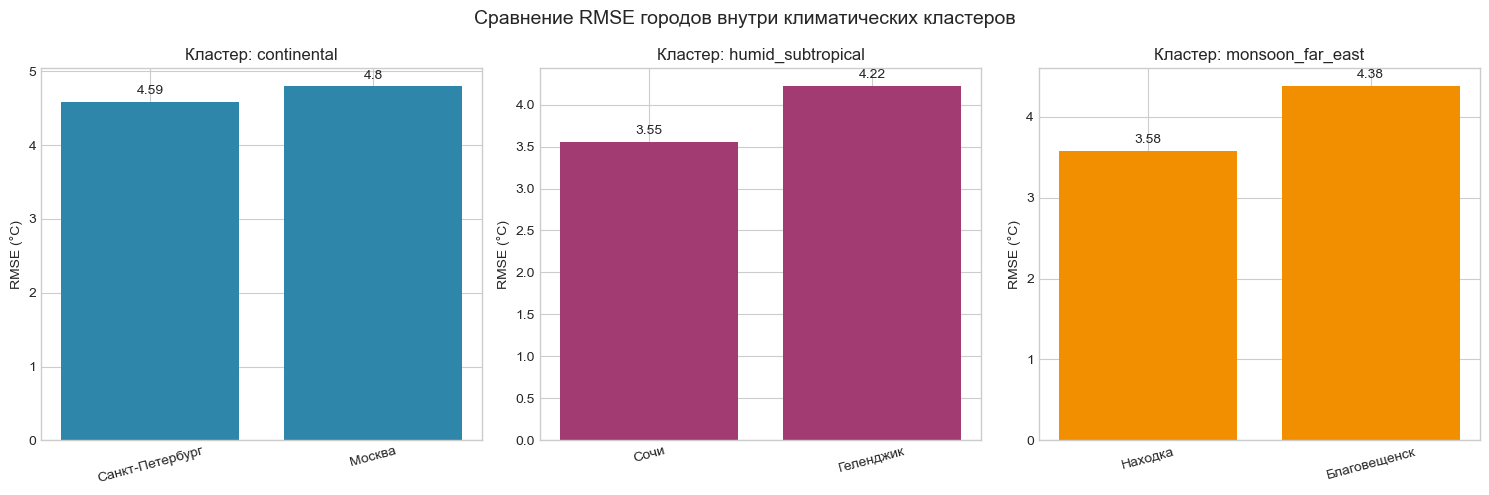

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, cluster in enumerate(["continental", "humid_subtropical", "monsoon_far_east"]):
    ax = axes[idx]
    cluster_data = forecast_df[forecast_df["climate_cluster"] == cluster]
    
    if len(cluster_data) > 0:
        bars = ax.bar(cluster_data["city"], cluster_data["RMSE"], 
                      color=CLIMATE_COLORS.get(cluster, "#2E86AB"))
        ax.set_title(f"Кластер: {cluster}")
        ax.set_ylabel("RMSE (°C)")
        ax.tick_params(axis='x', rotation=15)
        
        # Подписи значений на столбцах
        for bar, val in zip(bars, cluster_data["RMSE"]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                   f"{val}", ha="center", fontsize=10)

plt.suptitle("Сравнение RMSE городов внутри климатических кластеров", fontsize=14)
plt.tight_layout()
plt.show()

ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ ПО ГОРОДАМ


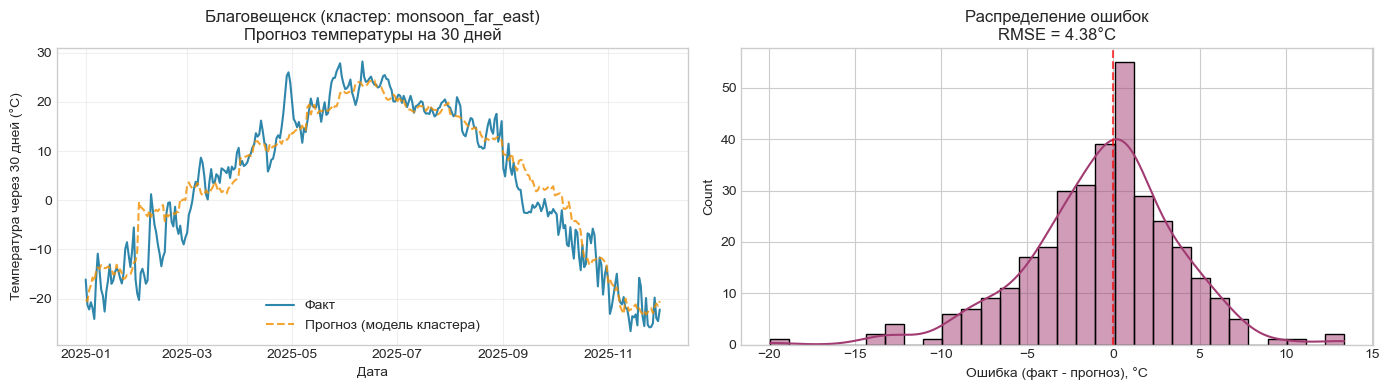

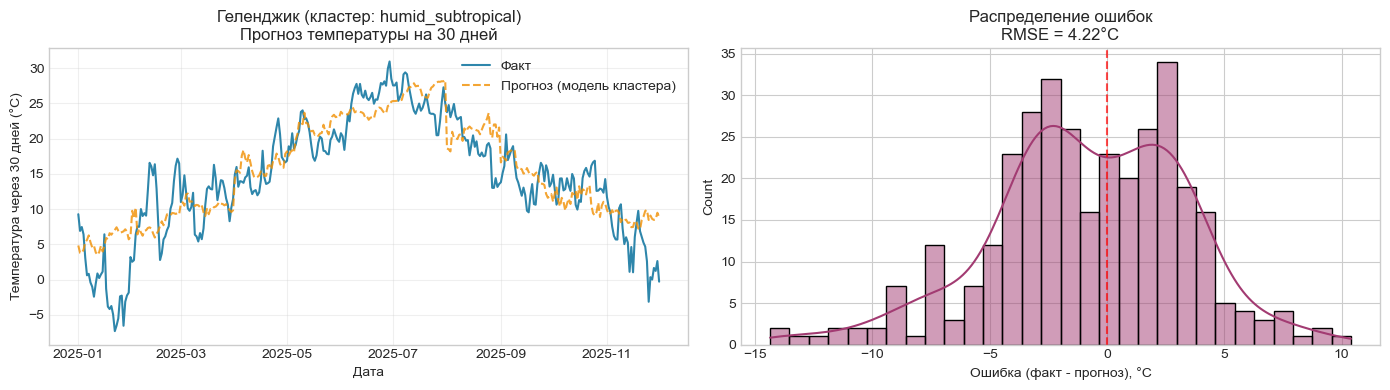

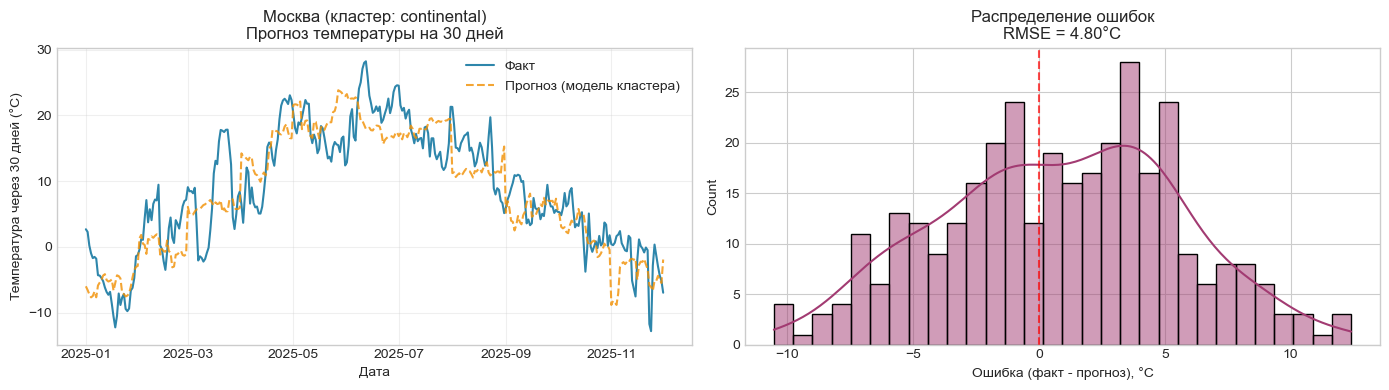

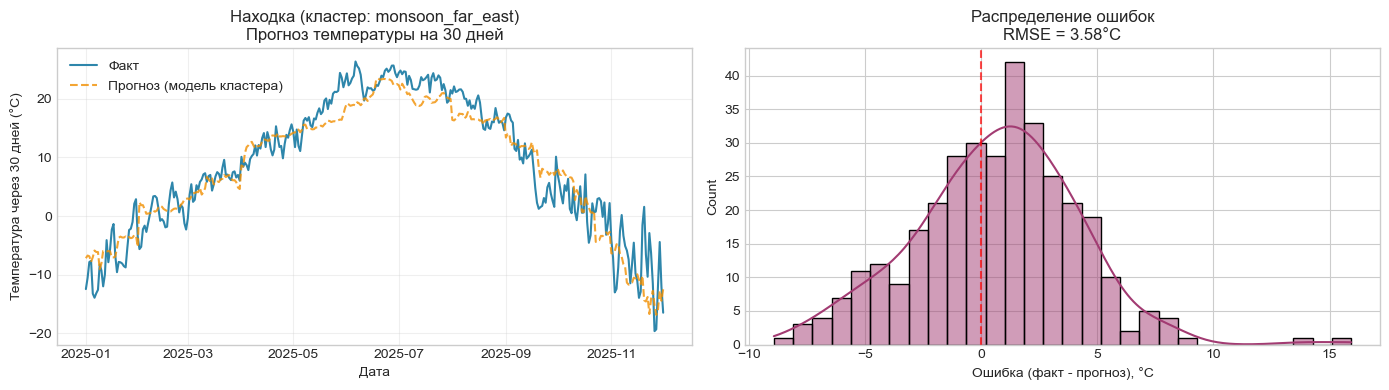

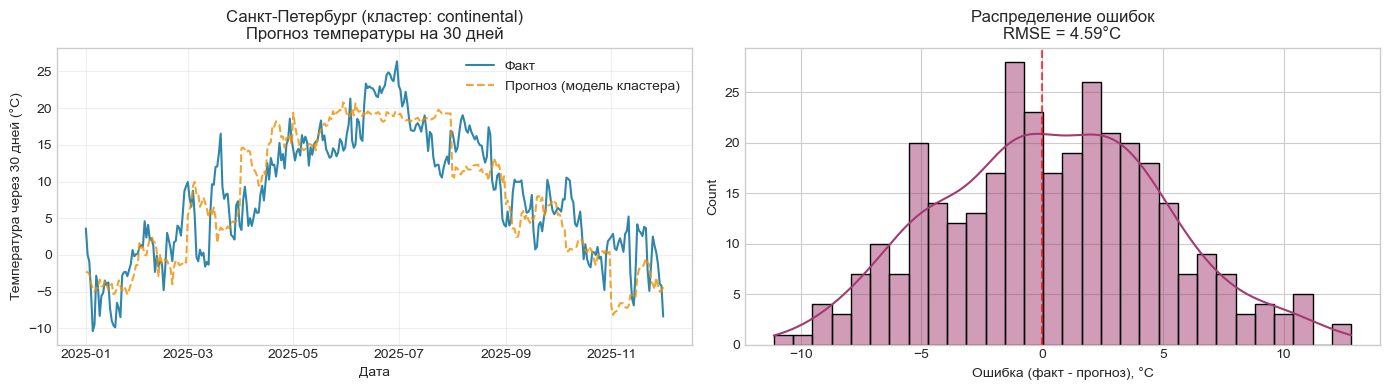

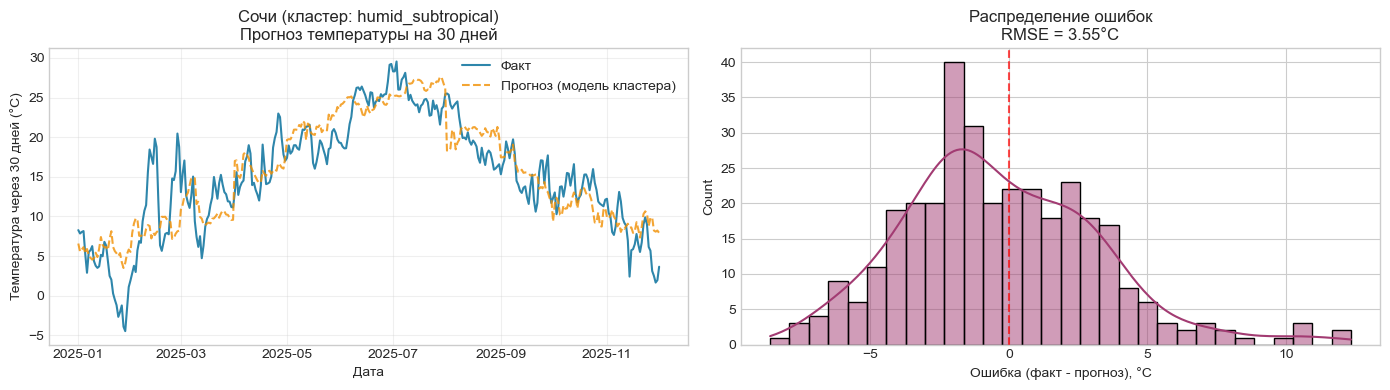

In [118]:
# ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ ДЛЯ КАЖДОГО ГОРОДА
print("ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ ПО ГОРОДАМ")

for city in daily_forecast["city"].unique():
    cluster = CITY_TO_CLIMATE[city]
    model = cluster_models[cluster]
    
    city_df = daily_forecast[daily_forecast["city"] == city]
    test_df = city_df[city_df["date"].dt.year == 2025]
    
    X_test = test_df[feat_cols]
    y_true = test_df["target_t30"].values
    y_pred = model.predict(X_test)
    
    plt.figure(figsize=(14, 4))
    
    # Основной график
    plt.subplot(1, 2, 1)
    plt.plot(test_df["date"].values, y_true, label="Факт", linewidth=1.5, color="#2E86AB")
    plt.plot(test_df["date"].values, y_pred, label="Прогноз (модель кластера)", 
             alpha=0.8, linewidth=1.5, color="#F18F01", linestyle="--")
    plt.title(f"{city} (кластер: {cluster})\nПрогноз температуры на 30 дней")
    plt.xlabel("Дата")
    plt.ylabel("Температура через 30 дней (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Гистограмма ошибок
    plt.subplot(1, 2, 2)
    residuals = y_true - y_pred
    sns.histplot(residuals, bins=30, kde=True, color="#A23B72")
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.7)
    plt.title(f"Распределение ошибок\nRMSE = {np.sqrt(np.mean(residuals**2)):.2f}°C")
    plt.xlabel("Ошибка (факт - прогноз), °C")
    
    plt.tight_layout()
    plt.show()

In [119]:
# АНАЛИЗ ОСТАТКОВ ПО ГОРОДАМ
print("АНАЛИЗ ОСТАТКОВ ПО ГОРОДАМ")

for city in daily_forecast["city"].unique():
    cluster = CITY_TO_CLIMATE[city]
    model = cluster_models[cluster]
    
    city_df = daily_forecast[daily_forecast["city"] == city]
    test_df = city_df[city_df["date"].dt.year == 2025]
    
    X_test = test_df[feat_cols]
    y_true = test_df["target_t30"].values
    y_pred = model.predict(X_test)
    
    residuals = y_true - y_pred
    
    print(f"\n{city} (кластер: {cluster}):")
    
    # Тест Шапиро-Уилка
    if len(residuals) >= 3:
        _, shapiro_p = shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
        print(f"   Шапиро-Уилк: p-value = {shapiro_p:.6f} ({'нормальные' if shapiro_p > 0.05 else 'не нормальные'})")
    
    # Тест Льюнга-Бокса
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb_result["lb_pvalue"].iloc[0]
    print(f"   Льюнг-Бокс (lag=10): p-value = {lb_p:.6f} ({'нет автокорр.' if lb_p > 0.05 else 'есть автокорр.'})")

АНАЛИЗ ОСТАТКОВ ПО ГОРОДАМ

Благовещенск (кластер: monsoon_far_east):
   Шапиро-Уилк: p-value = 0.000019 (не нормальные)
   Льюнг-Бокс (lag=10): p-value = 0.000000 (есть автокорр.)

Геленджик (кластер: humid_subtropical):
   Шапиро-Уилк: p-value = 0.001174 (не нормальные)
   Льюнг-Бокс (lag=10): p-value = 0.000000 (есть автокорр.)

Москва (кластер: continental):
   Шапиро-Уилк: p-value = 0.076055 (нормальные)
   Льюнг-Бокс (lag=10): p-value = 0.000000 (есть автокорр.)

Находка (кластер: monsoon_far_east):
   Шапиро-Уилк: p-value = 0.002553 (не нормальные)
   Льюнг-Бокс (lag=10): p-value = 0.000000 (есть автокорр.)

Санкт-Петербург (кластер: continental):
   Шапиро-Уилк: p-value = 0.298172 (нормальные)
   Льюнг-Бокс (lag=10): p-value = 0.000000 (есть автокорр.)

Сочи (кластер: humid_subtropical):
   Шапиро-Уилк: p-value = 0.000042 (не нормальные)
   Льюнг-Бокс (lag=10): p-value = 0.000000 (есть автокорр.)


1. ПОДХОД:
   • Одна модель RandomForestRegressor на климатический кластер
   • Прогноз для каждого города отдельно (моделью своего кластера)
   • Горизонт прогноза: 30 дней

2. Val RMSE МОДЕЛЕЙ КЛАСТЕРОВ:
   • humid_subtropical (Сочи, Геленджик): 3.59°C (лучший)
   • monsoon_far_east (Благовещенск, Находка): 4.00°C
   • continental (Москва, СПб): 4.61°C (худший)

3. РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ ПО ГОРОДАМ (RMSE):
   • Сочи: 3.55°C (лучший)
   • Находка: 3.58°C
   • Геленджик: 4.22°C
   • Благовещенск: 4.38°C
   • Санкт-Петербург: 4.59°C
   • Москва: 4.80°C (худший)

4. Direction ACC (точность направления):
   • Сочи: 0.539 (лучший, выше случайного)
   • Все остальные: 0.50-0.52 (случайный уровень)

5. АНАЛИЗ ОСТАТКОВ:
   • Тест Шапиро-Уилка: для большинства городов остатки НЕ нормальные
   • Тест Льюнга-Бокса: для ВСЕХ городов есть автокорреляция остатков

6. ВЫВОДЫ ПО ПРОГНОЗИРОВАНИЮ:
   • Лучшие прогнозы: Сочи и Находка (устойчивый климат)
   • Худшие прогнозы: Москва и СПб (высокая изменчивость)
   • Обучение на кластере дает преимущество (больше данных)
   • Направление изменений предсказывается на уровне случайности